# 📊 Phase 2 – Descriptive Analysis & Exploratory Data Evaluation

Following the completion of structural validation in Phase 1, the datasets are now analytically prepared for systematic exploration. All structural inconsistencies have been resolved while preserving the original integrity of the operational data.

This phase focuses on examining statistical behavior, distributional characteristics, temporal patterns, and operational dynamics within the Port Authority datasets.

The objectives of this phase are to:

- Quantify central tendency and dispersion across key operational metrics
- Evaluate variability and distribution structure
- Identify temporal trends and seasonality effects
- Examine traffic composition and payment behavior
- Assess facility-level performance indicators
- Detect anomalies or irregular patterns within the data

Each dataset will be analyzed independently to establish a clear understanding of its internal structure before any cross-dataset synthesis is introduced.

The Traffic dataset, representing the largest and most operationally significant component, will be examined first.

## Environment Setup

In [1]:
# =========================================
# Import Libraries & Configure Environment
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
sns.set_context("notebook")

print("Environment ready.")

Environment ready.


## Load Processed Datasets

In [2]:
traffic_df = pd.read_csv(
    "../data/processed/traffic_cleaned.csv",
    parse_dates=["DATE"]
)

bus_df = pd.read_csv(
    "../data/processed/bus_cleaned.csv",
    parse_dates=["Start_Date", "End_Date"]
)

passenger_df = pd.read_csv(
    "../data/processed/passenger_cleaned.csv",
    parse_dates=["Start_Date", "End_Date"]
)

speeds_df = pd.read_csv(
    "../data/processed/speeds_cleaned.csv",
    parse_dates=["Month_Year"]
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 🚦Traffic Dataset – Descriptive Statistical Overview

### Variable Selection for Descriptive Analysis

The Traffic dataset contains operational, categorical, and time-based variables.  

For descriptive statistical evaluation, only continuous numerical volume metrics are selected.  
Identifier variables (facility, lane, mode) and time variables are excluded at this stage, as central tendency and dispersion measures are not meaningful for categorical data.

The focus here is on traffic volume behavior and its distributional characteristics.

## Variable Selection for Descriptive Statistics

### Dataset Structure Overview

The Traffic dataset contains 30 variables operating at a lane × facility × time-interval grain.  
The variables fall into four structural categories:

- **Continuous operational variables** → traffic volumes and payment metrics  
- **Detailed vehicle classification variables** → CLASS 1–11  
- **Categorical identifiers** → facility, lane, operational mode  
- **Time-based variables** → date and time components  

For the initial descriptive statistical overview, only continuous operational volume variables are selected.

---

### Included Variables

The following variables are used for descriptive statistics:

- TOTAL  
- CASH  
- EZPASS  
- VIOLATION  
- Autos  
- Small_T  
- Large_T  
- Buses  

These variables directly measure traffic intensity, payment behavior, violation magnitude, and vehicle-type composition.

---

### Excluded Variables (At This Stage)

- **CLASS 1–11** → represent granular vehicle segmentation and contain analytical missingness. They will be analyzed separately in a vehicle-class composition section.
- **Facility & Lane identifiers** → categorical variables not suitable for central tendency or dispersion measures.
- **Time variables (DATE, TIME, Month, Yr, Day_Name)** → reserved for temporal and seasonality analysis.

---

### Rationale

Restricting the analysis to continuous operational variables ensures that:

- Summary statistics reflect true volume behavior  
- Granular segmentation does not distort interpretation  
- Categorical identifiers do not bias numerical metrics  
- Temporal effects are analyzed in a dedicated section  

This establishes a clean statistical baseline before moving into EDA and segmentation analysis.

In [3]:
# =========================================================
# Traffic Dataset – Descriptive Statistical Overview
# =========================================================

# Select core operational variables
traffic_volume_vars = [
    "TOTAL",
    "CASH",
    "EZPASS",
    "VIOLATION",
    "Autos",
    "Small_T",
    "Large_T",
    "Buses"
]

traffic_selected = traffic_df[traffic_volume_vars]

# Basic descriptive statistics
desc_stats = traffic_selected.describe().T

# Add additional analytical metrics
desc_stats["range"] = desc_stats["max"] - desc_stats["min"]
desc_stats["CV"] = desc_stats["std"] / desc_stats["mean"]  # volatility indicator
desc_stats["skewness"] = traffic_selected.skew()

desc_stats

,count,mean,std,min,25%,50%,75%,max,range,CV,skewness
TOTAL,"5,383,378.00",270.17,260.60,0.00,88.00,199.00,357.00,"3,938.00","3,938.00",0.96,1.73
CASH,"5,383,378.00",36.36,52.98,0.00,0.00,3.00,61.00,817.00,817.00,1.46,1.78
EZPASS,"5,383,378.00",218.75,231.69,0.00,47.00,138.00,315.00,"3,936.00","3,936.00",1.06,1.60
VIOLATION,"5,383,378.00",15.07,22.64,0.00,2.00,7.00,19.00,789.00,789.00,1.50,3.94
Autos,"5,383,378.00",246.76,249.09,0.00,74.00,176.00,325.00,"3,155.00","3,155.00",1.01,1.85
Small_T,"5,383,378.00",9.00,18.83,0.00,0.00,2.00,9.00,426.00,426.00,2.09,4.96
Large_T,"5,383,378.00",8.58,24.18,0.00,0.00,0.00,5.00,537.00,537.00,2.82,5.81
Buses,"5,383,378.00",5.83,27.45,0.00,0.00,1.00,3.00,680.00,680.00,4.70,12.75


In [4]:
# Core operational variables
traffic_volume_vars = [
    "TOTAL",
    "CASH",
    "EZPASS",
    "VIOLATION",
    "Autos",
    "Small_T",
    "Large_T",
    "Buses"
]

traffic_selected = traffic_df[traffic_volume_vars]

# -----------------------------
# Basic Descriptive Statistics
# -----------------------------
desc_stats = traffic_selected.describe().T

# Additional distribution metrics
desc_stats["range"] = desc_stats["max"] - desc_stats["min"]
desc_stats["CV"] = desc_stats["std"] / desc_stats["mean"]
desc_stats["skewness"] = traffic_selected.skew()

# -----------------------------
# Percent Composition Metrics
# -----------------------------

# Overall totals (dataset-level composition)
total_vehicles = traffic_df["TOTAL"].sum()

composition = pd.DataFrame({
    "Total_Sum": traffic_selected.sum()
})

composition["Percent_of_TOTAL"] = (
    composition["Total_Sum"] / total_vehicles
) * 100

# -----------------------------
# Payment & Violation Rates
# -----------------------------

traffic_df["Violation_Rate_%"] = (
    traffic_df["VIOLATION"] / traffic_df["TOTAL"]
) * 100

traffic_df["Cash_Rate_%"] = (
    traffic_df["CASH"] / traffic_df["TOTAL"]
) * 100

traffic_df["EZPass_Rate_%"] = (
    traffic_df["EZPASS"] / traffic_df["TOTAL"]
) * 100

rate_summary = traffic_df[[
    "Violation_Rate_%",
    "Cash_Rate_%",
    "EZPass_Rate_%"
]].describe().T

# Display outputs
print("=== Descriptive Statistics ===")
display(desc_stats)

print("\n=== Overall Composition (% of TOTAL) ===")
display(composition)

print("\n=== Rate Distribution Statistics ===")
display(rate_summary)

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max,range,CV,skewness
TOTAL,"5,383,378.00",270.17,260.60,0.00,88.00,199.00,357.00,"3,938.00","3,938.00",0.96,1.73
CASH,"5,383,378.00",36.36,52.98,0.00,0.00,3.00,61.00,817.00,817.00,1.46,1.78
EZPASS,"5,383,378.00",218.75,231.69,0.00,47.00,138.00,315.00,"3,936.00","3,936.00",1.06,1.60
VIOLATION,"5,383,378.00",15.07,22.64,0.00,2.00,7.00,19.00,789.00,789.00,1.50,3.94
Autos,"5,383,378.00",246.76,249.09,0.00,74.00,176.00,325.00,"3,155.00","3,155.00",1.01,1.85
Small_T,"5,383,378.00",9.00,18.83,0.00,0.00,2.00,9.00,426.00,426.00,2.09,4.96
Large_T,"5,383,378.00",8.58,24.18,0.00,0.00,0.00,5.00,537.00,537.00,2.82,5.81
Buses,"5,383,378.00",5.83,27.45,0.00,0.00,1.00,3.00,680.00,680.00,4.70,12.75



=== Overall Composition (% of TOTAL) ===


,Total_Sum,Percent_of_TOTAL
TOTAL,1454450250,100.00
CASH,195756642,13.46
EZPASS,1177592218,80.96
VIOLATION,81105494,5.58
Autos,1328400296,91.33
Small_T,48436522,3.33
Large_T,46205975,3.18
Buses,31407457,2.16



=== Rate Distribution Statistics ===


,count,mean,std,min,25%,50%,75%,max
Violation_Rate_%,"5,383,242.00",6.96,12.75,0.00,1.92,3.72,6.91,400.00
Cash_Rate_%,"5,383,242.00",18.08,24.59,0.00,0.00,6.42,27.69,100.00
EZPass_Rate_%,"5,383,242.00",74.96,24.81,0.00,63.33,83.26,94.62,207.62


## Traffic Dataset – Key Statistical Insights

### 1️⃣ Traffic Volume Behavior

- The average traffic per lane-time interval is **270 vehicles**, with a median of 199.
- Mean > median and skewness > 1 indicate strong right-skewness.
- Maximum values (≈3,900 vehicles) suggest extreme peak intervals.

**Interpretation:**  
Traffic is highly uneven and concentrated in specific time windows or facilities. Peak periods likely drive congestion behavior.

---

### 2️⃣ Payment Structure

- **EZPASS accounts for ~81%** of total traffic.
- **Cash accounts for ~13%.**
- **Violations represent ~5.6%** of total vehicles.

**Interpretation:**  
Electronic tolling is structurally dominant. Pricing and congestion policy analysis must focus primarily on EZPASS patterns.

---

### 3️⃣ Toll Violations

- Mean violation rate ≈ 7%.
- Highly right-skewed distribution (skewness ≈ 3.9).
- Extreme maximum rates observed due to very low traffic intervals.

**Interpretation:**  
Violations are generally low but episodically spike. Rate instability suggests that low-volume intervals inflate percentages, requiring controlled filtering or aggregation in later analysis.

---

### 4️⃣ Vehicle Composition

- **Autos represent ~91%** of total traffic.
- Small and large trucks together account for ~6–7%.
- Buses represent ~2% of total traffic.
- Truck and bus variables show high volatility (CV > 2 and extreme skewness).

**Interpretation:**  
Traffic is overwhelmingly passenger-vehicle driven. Commercial and bus traffic is sparse but highly concentrated in specific intervals.

---

### 5️⃣ Variability & Distribution Shape

- Most variables have CV ≥ 1, indicating high variability.
- All major traffic metrics are right-skewed.
- Extreme values are present across categories.

**Interpretation:**  
Traffic data is non-normal and peak-driven.  
Future modeling may require aggregation, transformation, or outlier handling.

---

## Analytical Conclusion

The Traffic dataset exhibits:

- Strong peak concentration behavior  
- Clear dominance of passenger vehicles and electronic tolling  
- Episodic violation spikes  
- Highly skewed distributions  

These findings establish the statistical baseline for:

- Temporal seasonality analysis  
- Facility-level segmentation  
- Violation rate investigation  
- Congestion pattern exploration  
- Predictive modeling preparation  

The next step is distributional visualization and controlled aggregation for exploratory analysis.

## Traffic Dataset – Distribution Analysis (Lane-Time Grain)

Before aggregating the dataset, we examine the raw distribution of key traffic variables.

This helps us:

- Confirm distribution shape (normal vs skewed)
- Identify extreme outliers
- Assess peak-driven behavior
- Determine whether aggregation is required

Variables examined:

- TOTAL (overall traffic intensity)
- VIOLATION (toll violations)
- Autos (dominant vehicle class)

This visualization is performed at the original lane × time interval grain.

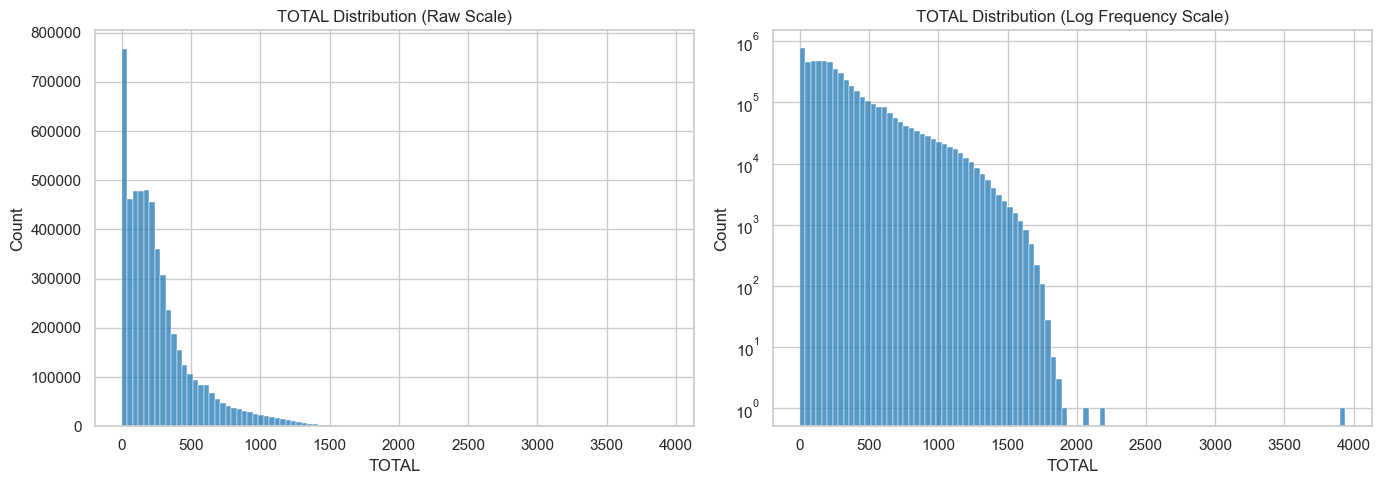

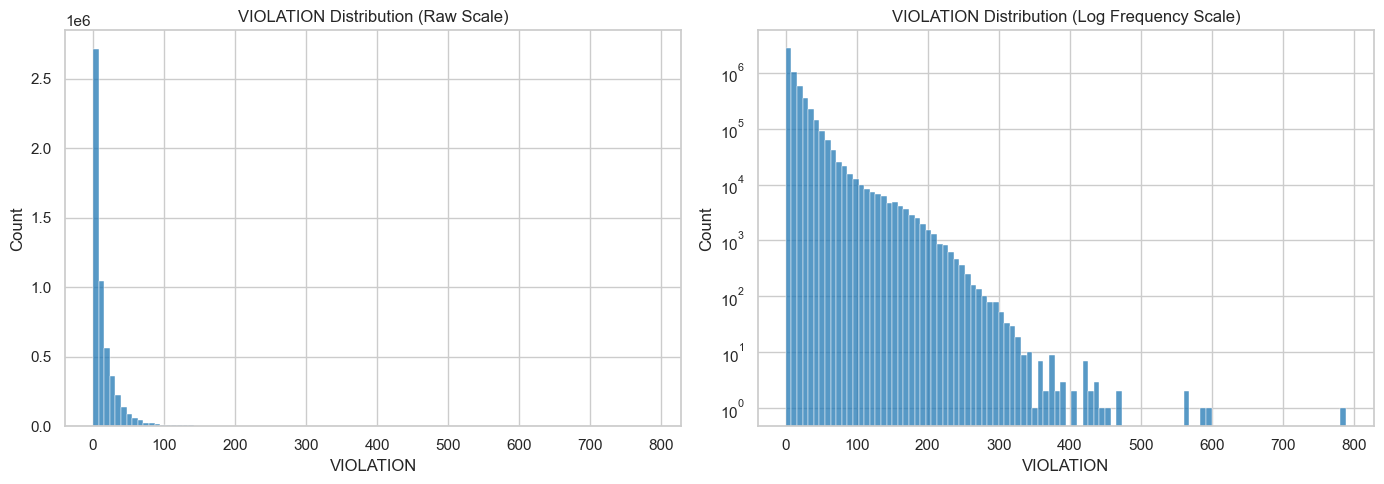

In [6]:
# =========================================================
# Traffic Dataset – Key Distribution Analysis
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
# -----------------------------
# TOTAL Distribution
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(traffic_df["TOTAL"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("TOTAL Distribution (Raw Scale)")
axes[0].set_xlabel("TOTAL")

sns.histplot(traffic_df["TOTAL"], bins=100, kde=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("TOTAL Distribution (Log Frequency Scale)")
axes[1].set_xlabel("TOTAL")

plt.tight_layout()
plt.show()
# -----------------------------
# VIOLATION Distribution
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(traffic_df["VIOLATION"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("VIOLATION Distribution (Raw Scale)")
axes[0].set_xlabel("VIOLATION")

sns.histplot(traffic_df["VIOLATION"], bins=100, kde=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("VIOLATION Distribution (Log Frequency Scale)")
axes[1].set_xlabel("VIOLATION")

plt.tight_layout()
plt.show()

## Distribution Analysis – TOTAL and VIOLATION (Lane × Time Grain)

The distribution analysis focuses on **TOTAL** and **VIOLATION** because TOTAL represents overall system load and congestion behavior, while VIOLATION captures enforcement-sensitive and anomaly-driven activity. Other variables (e.g., Autos, Cash, EZPASS) are structural components of TOTAL and follow similar distributional patterns, adding no distinct insight at this stage.

### 1️⃣ TOTAL Traffic Distribution

The TOTAL traffic distribution is strongly right-skewed.

Key observations:

- Most observations fall within a lower traffic range.
- A small number of intervals show extremely high traffic (long right tail).
- The mean exceeds the median, confirming peak-driven behavior.
- The log-scale plot reveals that extreme values are rare but operationally real.

**Interpretation:**  
Traffic intensity is not uniformly distributed across time intervals. The dataset contains many low-traffic intervals and a limited number of high-demand peaks, confirming that traffic behavior is concentrated in specific windows rather than evenly distributed.

---

### 2️⃣ VIOLATION Distribution

The VIOLATION variable also exhibits strong right-skewness.

Key observations:

- The majority of intervals have low violation counts.
- Rare intervals experience substantial violation spikes.
- The log-scale plot confirms that extreme violation events are infrequent but significant.

**Interpretation:**  
Violations are generally low but episodic. Rate instability at the granular level may occur when TOTAL traffic is very small, suggesting that violation rate analysis should not be performed at the lane-time grain without aggregation.

---

### 3️⃣ Why Log Scale Was Used

The raw histograms compress rare high-volume observations due to the dominance of lower-frequency bins. Using a log frequency scale:

- Makes the long tail visible  
- Confirms the exponential decay structure  
- Highlights that extreme values are sparse but valid  

Log scaling is appropriate when distributions span multiple magnitudes, as observed here.

---

### 4️⃣ Analytical Implication

At the lane × time interval grain:

- Traffic is peak-driven and highly skewed  
- Many low-volume intervals inflate volatility measures  
- Rate calculations may become unstable  

This confirms the need for temporal aggregation before deeper exploratory analysis. The next step is daily-level aggregation to stabilize patterns and produce operationally meaningful insights.

## 📅 Daily Aggregation

### Stage 1 – System-Level Daily Aggregation

The Traffic dataset is currently at a lane × time interval grain, which introduces significant volatility and denominator instability.

To obtain operationally meaningful insights, the dataset is aggregated at the DATE level across all facilities and lanes.

This aggregation:

- Reduces noise from low-traffic intervals
- Stabilizes violation rate calculations
- Produces system-level traffic trends
- Prepares the dataset for temporal pattern analysis

The following metrics are computed at the daily level:

- TOTAL traffic
- CASH payments
- EZPASS payments
- VIOLATION counts
- Violation rate (%)
- Payment composition (%)

In [7]:

# Ensure DATE is datetime
traffic_df["DATE"] = pd.to_datetime(traffic_df["DATE"])

# Aggregate at DATE level
daily_traffic = (
    traffic_df
    .groupby("DATE")
    .agg({
        "TOTAL": "sum",
        "CASH": "sum",
        "EZPASS": "sum",
        "VIOLATION": "sum"
    })
    .reset_index()
)

# -----------------------------
# Calculate Rates & Composition
# -----------------------------

daily_traffic["Violation_Rate_%"] = (
    daily_traffic["VIOLATION"] / daily_traffic["TOTAL"]
) * 100

daily_traffic["Cash_Rate_%"] = (
    daily_traffic["CASH"] / daily_traffic["TOTAL"]
) * 100

daily_traffic["EZPass_Rate_%"] = (
    daily_traffic["EZPASS"] / daily_traffic["TOTAL"]
) * 100

# -----------------------------
# Daily Descriptive Statistics
# -----------------------------

daily_desc = daily_traffic.drop(columns="DATE").describe().T

daily_desc["CV"] = daily_desc["std"] / daily_desc["mean"]
daily_desc["skewness"] = daily_traffic.drop(columns="DATE").skew()

daily_desc

,count,mean,std,min,25%,50%,75%,max,CV,skewness
TOTAL,"4,534.00","320,787.44","36,132.59","28,703.00","309,818.75","327,651.00","342,086.75","382,569.00",0.11,-2.89
CASH,"4,534.00","43,175.26","14,810.08","3,294.00","32,513.50","43,514.00","53,712.00","82,057.00",0.34,-0.18
EZPASS,"4,534.00","259,724.79","29,781.00","22,272.00","251,953.50","266,182.00","276,852.00","305,625.00",0.11,-2.89
VIOLATION,"4,534.00","17,888.29","9,931.21","2,170.00","10,271.75","13,409.50","23,192.50","57,615.00",0.56,1.19
Violation_Rate_%,"4,534.00",5.70,3.46,1.83,3.15,4.19,7.06,19.13,0.61,1.48
Cash_Rate_%,"4,534.00",13.32,4.21,3.06,9.92,13.48,16.29,25.86,0.32,-0.13
EZPass_Rate_%,"4,534.00",80.97,2.51,71.13,79.28,81.06,82.92,85.99,0.03,-0.31


## Daily Aggregation – Key Insights

Aggregating traffic data at the DATE level significantly stabilizes the dataset.

#### Volatility Reduction
The coefficient of variation for TOTAL traffic decreased from ~0.96 (lane-level) to 0.11 (daily-level), confirming that lane-level variability was largely noise.

#### Skewness Shift
Daily TOTAL traffic now exhibits negative skewness (−2.89), indicating occasional unusually low-traffic days rather than frequent extreme peaks.

#### Stable Payment Structure
EZPass usage remains highly stable at ~81% daily, with minimal variability (CV = 0.03), confirming structural dominance of electronic tolling.

#### Violation Rate Stabilization
Daily violation rates average 5.7% with moderate variability, and extreme distortions observed at lane-level disappear after aggregation.

#### Conclusion
Daily aggregation transforms the dataset from volatile and peak-driven to stable and operationally interpretable. All subsequent temporal analysis should be conducted at daily or higher aggregation levels.

## Stage 2 – Daily Trend Visualization

After aggregating traffic data at the daily level, we examine temporal trends.

This analysis helps identify:

- Long-term growth or decline patterns
- Structural breaks or abnormal periods
- Stability of payment composition
- Evolution of violation behavior over time

Daily-level visualization removes lane noise and reveals system-wide operational dynamics.

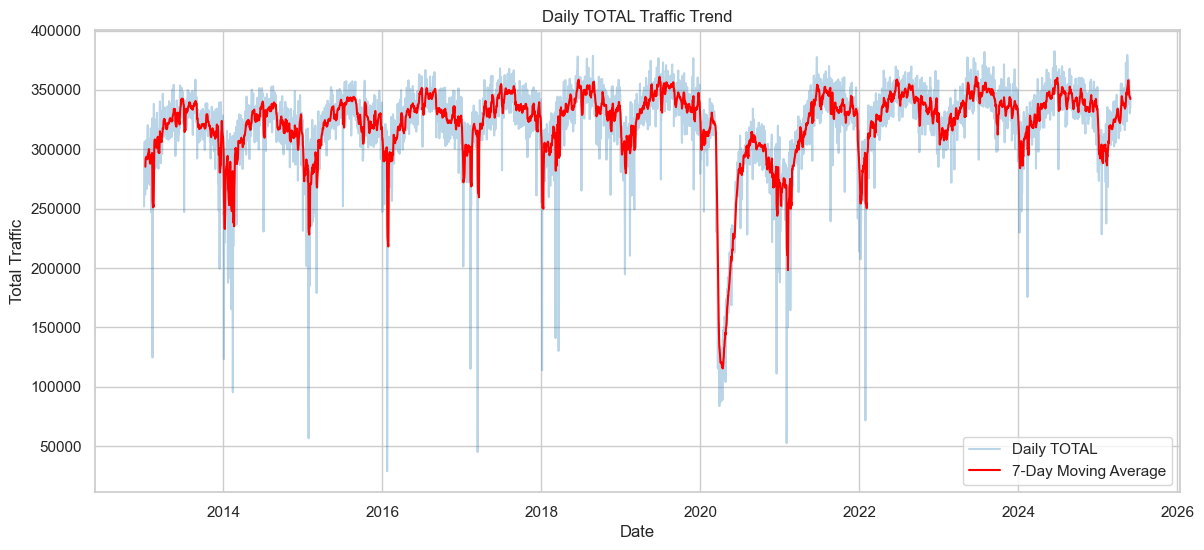

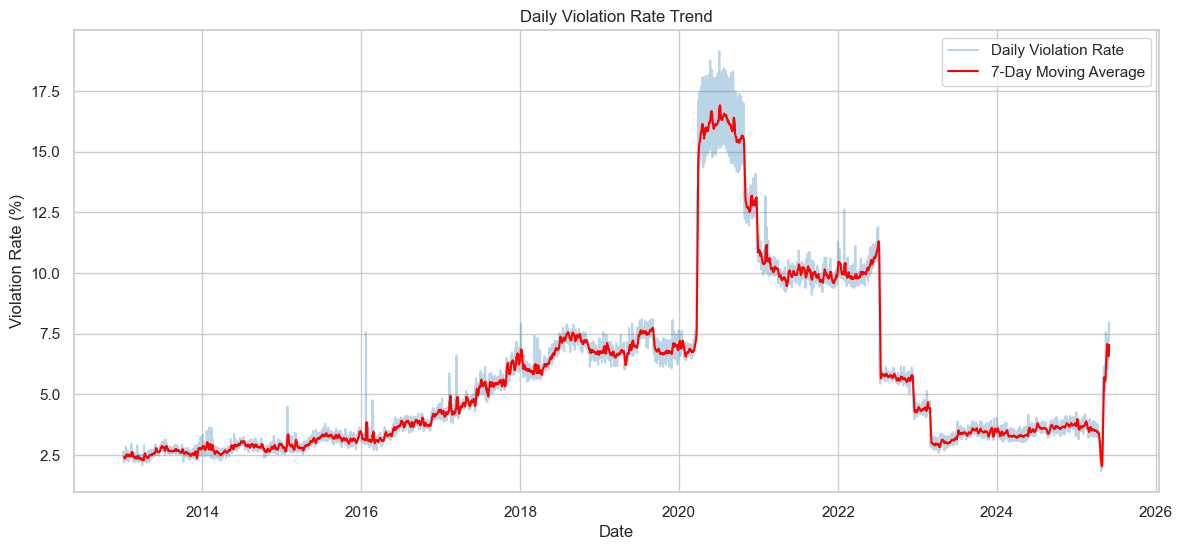

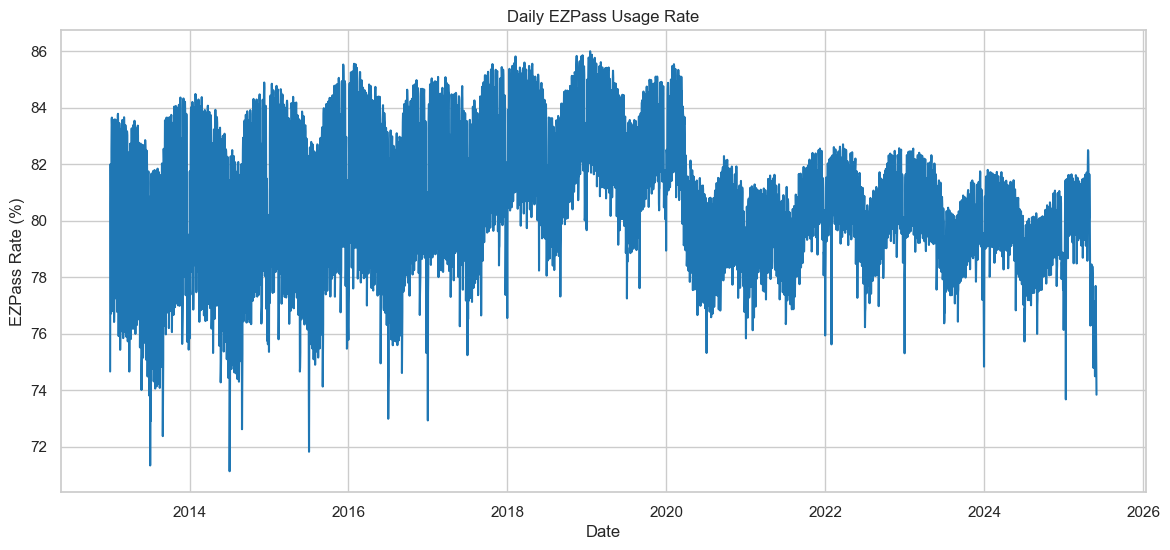

In [9]:

import matplotlib.pyplot as plt

# Sort by date (important)
daily_traffic = daily_traffic.sort_values("DATE")

# 7-day rolling average for smoothing
daily_traffic["TOTAL_7D_MA"] = daily_traffic["TOTAL"].rolling(window=7).mean()
daily_traffic["Violation_7D_MA"] = daily_traffic["Violation_Rate_%"].rolling(window=7).mean()

# -----------------------------
# Plot 1: TOTAL Traffic Trend
# -----------------------------

plt.figure(figsize=(14,6))
plt.plot(daily_traffic["DATE"], daily_traffic["TOTAL"], alpha=0.3, label="Daily TOTAL")
plt.plot(daily_traffic["DATE"], daily_traffic["TOTAL_7D_MA"], color="red", label="7-Day Moving Average")
plt.title("Daily TOTAL Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Total Traffic")
plt.legend()
plt.show()


# -----------------------------
# Plot 2: Violation Rate Trend
# -----------------------------

plt.figure(figsize=(14,6))
plt.plot(daily_traffic["DATE"], daily_traffic["Violation_Rate_%"], alpha=0.3, label="Daily Violation Rate")
plt.plot(daily_traffic["DATE"], daily_traffic["Violation_7D_MA"], color="red", label="7-Day Moving Average")
plt.title("Daily Violation Rate Trend")
plt.xlabel("Date")
plt.ylabel("Violation Rate (%)")
plt.legend()
plt.show()


# -----------------------------
# Plot 3: EZPass Rate Stability
# -----------------------------

plt.figure(figsize=(14,6))
plt.plot(daily_traffic["DATE"], daily_traffic["EZPass_Rate_%"])
plt.title("Daily EZPass Usage Rate")
plt.xlabel("Date")
plt.ylabel("EZPass Rate (%)")
plt.show()

## Daily Trend Analysis – Key Observations

### 1️⃣ Traffic Trend and Structural Break

Daily TOTAL traffic exhibits strong annual seasonality and a clear structural break in 2020. A significant decline is observed during the COVID period, followed by gradual recovery and stabilization.

This indicates the presence of multiple operational regimes (pre-2020 and post-2020), which must be considered in forecasting and policy analysis.

### 2️⃣ Violation Rate Dynamics

Violation rates show a gradual upward trend from 2013 to 2019, followed by a sharp increase in 2020 and a subsequent structural shift downward.

This suggests that violation behavior is influenced by policy, enforcement intensity, or systemic disruptions rather than purely traffic volume.

### 3️⃣ EZPass Adoption Stability

EZPass usage remains structurally dominant (~80%) with relatively low variability. While minor shifts occur during 2020, the adoption rate is largely stable over time.

This confirms electronic tolling as the primary payment mode and a stable component of system behavior.

### 4️⃣ Analytical Implication

Daily aggregation reveals:

- Clear seasonality
- Structural regime changes
- Policy-sensitive violation behavior
- Stable electronic payment dominance

These findings justify moving to seasonal analysis and facility-level segmentation.

---

## Stage 3 - Day-of-Week Pattern Analysis

### Objective

After identifying long-term trends and structural breaks in daily traffic, the next analytical layer is to examine **intra-week behavioral patterns**.

The goal is to determine whether traffic and payment behavior follow a consistent weekly structure (e.g., commuter-driven weekdays vs. leisure-driven weekends).

### Why This Step Is Important

Daily time-series data contains two types of variation:

- Long-term trend (multi-year movement)
- Short-term cyclicality (weekly repetition)

If strong weekday/weekend differences exist, then part of the daily volatility observed earlier is structural and recurring — not random noise.

Understanding this helps us:

- Identify commuter-driven behavior
- Detect weekend traffic shifts
- Evaluate violation rate sensitivity by day type
- Assess whether payment mode usage changes across the week

This step prevents us from incorrectly attributing weekly effects to seasonality or structural change.

### Methodology

1. Extracted **Day of Week** from the DATE variable.
2. Ordered weekdays chronologically (Monday → Sunday) to maintain interpretability.
3. Aggregated daily data to compute **average values per weekday** for:

   - TOTAL traffic volume
   - Violation Rate (%)
   - EZPass Usage Rate (%)

This provides a structural weekly profile of system behavior.

### Analytical Purpose

By isolating weekday effects, we can determine:

- Whether traffic is commuter-dominated
- Whether violations increase on specific days
- Whether electronic toll usage differs by day type

This layer completes the short-term behavioral analysis before moving into broader seasonal aggregation.

In [10]:
# --------------------------------------
# Extract Day-of-Week
# --------------------------------------

daily_traffic["Day_of_Week"] = daily_traffic["DATE"].dt.day_name()

# Define proper weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]

daily_traffic["Day_of_Week"] = pd.Categorical(
    daily_traffic["Day_of_Week"],
    categories=weekday_order,
    ordered=True
)
# --------------------------------------
# Compute Weekday Averages
# --------------------------------------

weekday_pattern = (
    daily_traffic
    .groupby("Day_of_Week")
    .agg({
        "TOTAL": "mean",
        "Violation_Rate_%": "mean",
        "EZPass_Rate_%": "mean"
    })
    .reset_index()
)

weekday_pattern

C:\Users\nanda\AppData\Local\Temp\ipykernel_12964\2182858382.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Day_of_Week")


,Day_of_Week,TOTAL,Violation_Rate_%,EZPass_Rate_%
0,Monday,"314,068.69",5.88,81.59
1,Tuesday,"312,573.68",5.64,82.59
2,Wednesday,"317,868.81",5.56,82.69
3,Thursday,"324,168.39",5.57,82.40
4,Friday,"330,533.62",5.79,80.60
5,Saturday,"325,567.70",5.74,78.09
6,Sunday,"320,720.71",5.73,78.85


## Weekday Behavioral Interpretation

### Traffic Volume

Traffic gradually increases through the week and peaks on Friday. Weekend traffic remains relatively strong, indicating that the system is not purely commuter-driven but supports substantial leisure and non-work travel.

### Violation Rate

Violation rates remain structurally stable across all weekdays, suggesting that enforcement behavior and compliance patterns are not strongly dependent on day type.

### EZPass Usage

EZPass usage is highest during weekdays and declines on weekends. This indicates a compositional shift in driver type during weekends, with a higher proportion of occasional or non-registered users.

### Analytical Implication

Weekly cyclicality exists but is moderate. Traffic demand remains high across all days, while payment mode composition varies more meaningfully than violation behavior.

## Stage 4 - Monthly Aggregation (Seasonality Detection)

### Objective

After evaluating daily trends and weekly cyclicality, the next analytical layer is to assess **monthly seasonality**.

The goal is to determine whether traffic and behavioral metrics exhibit recurring annual patterns such as:

- Summer traffic peaks  
- Winter slowdowns  
- Seasonal shifts in violation rates  
- Seasonal variation in EZPass adoption  

### Why Monthly Aggregation?

Daily data contains high-frequency noise driven by weekday structure and short-term fluctuations.

Aggregating to the monthly level:

- Smooths intra-week variation  
- Reduces noise  
- Highlights recurring yearly demand cycles  
- Improves interpretability of seasonal behavior  

This step allows us to distinguish structural long-term trend from recurring seasonal rhythm.

### Metrics Analyzed

At the monthly level, we compute the average values for:

- **TOTAL traffic volume**
- **Violation Rate (%)**
- **EZPass Usage Rate (%)**

These metrics capture:

- Demand intensity  
- Compliance behavior  
- Payment mode composition  

This stage completes the medium-term cyclical analysis before moving to deeper structural segmentation.

In [11]:
# --------------------------------------
# Create Year-Month Column
# --------------------------------------

daily_traffic["Year_Month"] = daily_traffic["DATE"].dt.to_period("M")

# --------------------------------------
# Monthly Aggregation
# --------------------------------------

monthly_traffic = (
    daily_traffic
    .groupby("Year_Month")
    .agg({
        "TOTAL": "mean",
        "Violation_Rate_%": "mean",
        "EZPass_Rate_%": "mean"
    })
    .reset_index()
)

# Convert back to timestamp for plotting
monthly_traffic["Year_Month"] = monthly_traffic["Year_Month"].dt.to_timestamp()

monthly_traffic.head()

,Year_Month,TOTAL,Violation_Rate_%,EZPass_Rate_%
0,2013-01-01,"292,342.87",2.46,80.91
1,2013-02-01,"289,552.61",2.46,80.80
2,2013-03-01,"310,753.29",2.37,80.16
3,2013-04-01,"321,276.27",2.42,80.69
4,2013-05-01,"327,034.84",2.56,80.16


Monthly averages were computed to smooth weekly fluctuations and expose recurring seasonal patterns.  
The aggregated table confirms stable monthly values, enabling seasonal visualization.

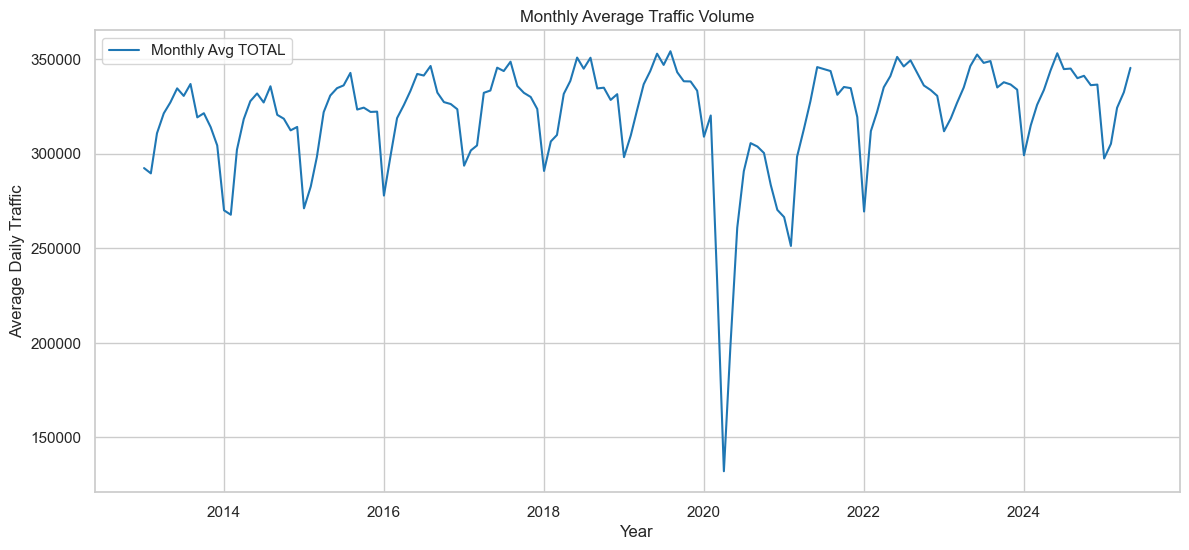

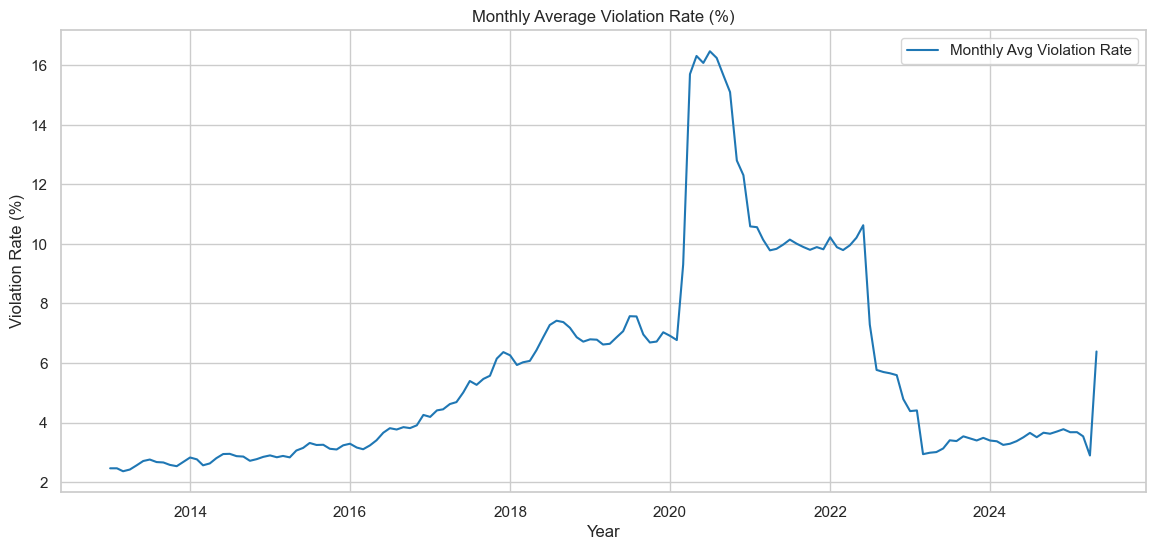

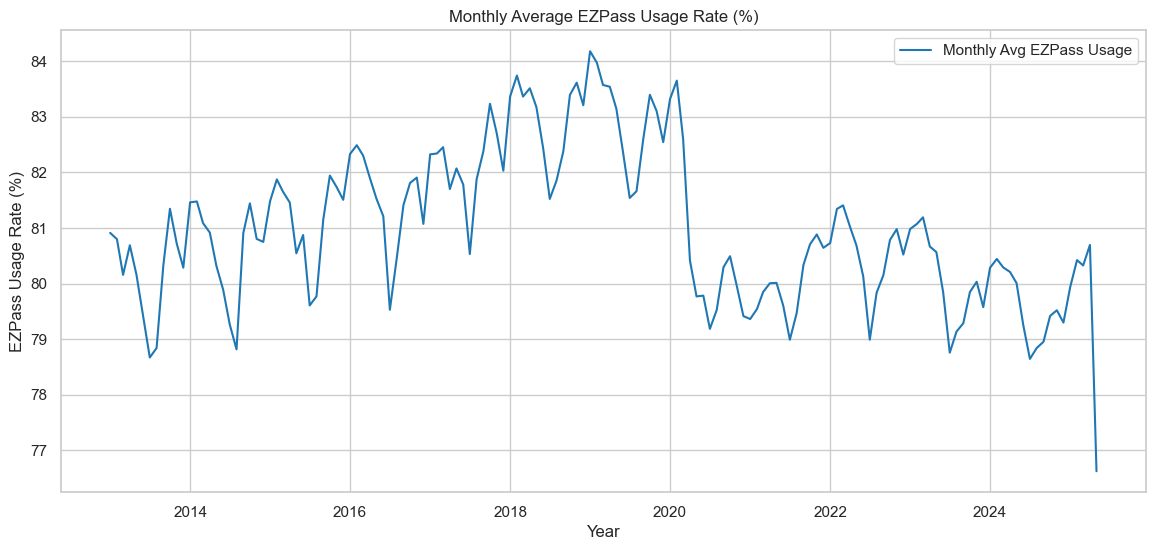

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(monthly_traffic["Year_Month"],
         monthly_traffic["TOTAL"],
         label="Monthly Avg TOTAL")

plt.title("Monthly Average Traffic Volume")
plt.xlabel("Year")
plt.ylabel("Average Daily Traffic")
plt.legend()
plt.show()


plt.figure(figsize=(14, 6))

plt.plot(monthly_traffic["Year_Month"],
         monthly_traffic["Violation_Rate_%"],
         label="Monthly Avg Violation Rate")

plt.title("Monthly Average Violation Rate (%)")
plt.xlabel("Year")
plt.ylabel("Violation Rate (%)")
plt.legend()
plt.show()


plt.figure(figsize=(14, 6))

plt.plot(monthly_traffic["Year_Month"],
         monthly_traffic["EZPass_Rate_%"],
         label="Monthly Avg EZPass Usage")

plt.title("Monthly Average EZPass Usage Rate (%)")
plt.xlabel("Year")
plt.ylabel("EZPass Usage Rate (%)")
plt.legend()
plt.show()

## Monthly Seasonality Analysis – Interpretation

### Traffic Volume (TOTAL)

Monthly traffic exhibits a clear recurring seasonal pattern. 
Across multiple years (excluding the 2020 structural break), traffic tends to:

- Rise through spring
- Peak during late spring / summer months
- Decline during late fall / winter

This confirms that system demand is seasonally driven and not purely commuter-based. The pronounced drop in 2020 represents a structural regime shift rather than seasonality.

### Violation Rate (%)

Violation rates do not display strong recurring seasonal cycles prior to 2020. 
Instead, they show:

- A gradual upward structural trend (2013–2019)
- A sharp regime spike in 2020
- A downward structural correction post-2022

This suggests violation behavior is more policy- or system-driven than seasonally driven.

### EZPass Usage Rate (%)

EZPass usage shows mild cyclical movement but remains structurally stable over time.

Seasonal variation is relatively small compared to structural shifts observed during the COVID period. This confirms electronic toll adoption is behaviorally stable and not strongly influenced by seasonal travel patterns.

### Analytical Implications

- Traffic volume demonstrates strong annual seasonality.
- Violation rate reflects structural regime changes rather than cyclical seasonality.
- EZPass adoption remains consistently dominant with limited seasonal sensitivity.
- The 2020 period represents a structural breakpoint that must be treated separately in future modeling.

This completes the medium-term cyclical analysis and prepares the foundation for structural regime comparison (Pre vs Post 2020).

## Stage 5 - Structural Regime Segmentation (Pre-2020 vs Post-2020)

### Objective

Earlier analysis revealed a pronounced structural break around 2020 across traffic volume, violation rates, and EZPass adoption.

The objective of this stage is to formally segment the dataset into two operational regimes:

- **Pre-2020 (Baseline Period)**
- **Post-2020 (Disruption & Recovery Period)**

This allows us to quantify how system behavior changed across regimes.

### Why Regime Segmentation?

Visual inspection showed:

- A severe traffic contraction in 2020
- A spike in violation rates
- Shifts in payment behavior

If these structural shifts are significant, modeling the entire time series as one homogeneous system would produce biased conclusions.

Segmenting the data allows us to:

- Compare average traffic levels
- Compare violation behavior
- Compare EZPass adoption
- Evaluate variance changes
- Identify whether recovery fully restored pre-2020 norms

This step validates whether 2020 represents a permanent structural shift or a temporary disruption.

In [13]:
# --------------------------------------
# Create Regime Indicator
# --------------------------------------

daily_traffic["Regime"] = daily_traffic["DATE"].apply(
    lambda x: "Pre-2020" if x.year < 2020 else "Post-2020"
)

daily_traffic[["DATE", "Regime"]].head()

# --------------------------------------
# Regime-Level Comparison
# --------------------------------------

regime_summary = (
    daily_traffic
    .groupby("Regime")
    .agg({
        "TOTAL": ["mean", "std"],
        "Violation_Rate_%": ["mean", "std"],
        "EZPass_Rate_%": ["mean", "std"]
    })
)

regime_summary

TOTAL           Violation_Rate_%      EZPass_Rate_%     
                mean       std             mean  std          mean  std
Regime                                                                 
Post-2020 317,566.73 43,535.52             7.38 4.28         80.12 1.65
Pre-2020  323,279.83 28,904.56             4.41 1.78         81.63 2.85

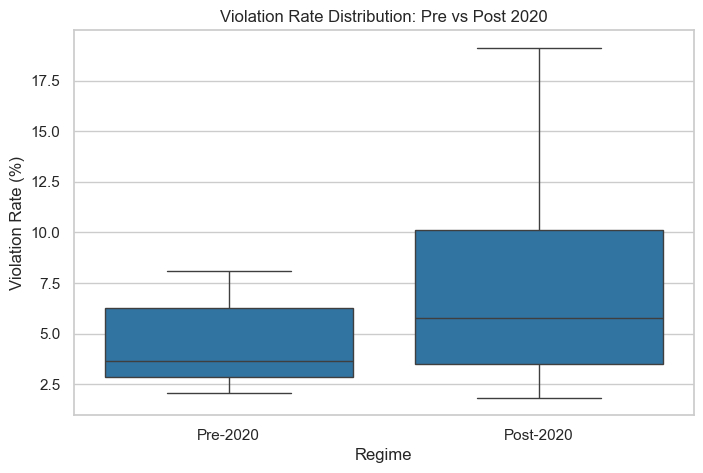

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=daily_traffic, x="Regime", y="Violation_Rate_%")
plt.title("Violation Rate Distribution: Pre vs Post 2020")
plt.ylabel("Violation Rate (%)")
plt.show()

## Structural Regime Comparison – Interpretation

The regime segmentation confirms a structural shift beginning in 2020.

#### Traffic Volume
Average traffic volume remains near pre-2020 levels, but variability increased significantly, indicating reduced system stability.

#### Violation Rate
Violation rates show a substantial structural increase in the post-2020 regime, suggesting a long-term shift in compliance behavior.

#### EZPass Usage
EZPass adoption slightly declined post-2020 but became more stable over time, indicating consolidation in electronic toll usage patterns.

#### Analytical Implication
The system did not revert fully to its pre-2020 structural behavior.  
Modeling and forecasting should account for regime segmentation rather than treating the dataset as homogeneous.

The boxplot confirms a clear upward shift in both the median and dispersion of violation rates post-2020, indicating a structural increase in compliance volatility rather than a temporary fluctuation.

## Stage 6 — Facility-Level Structural Analysis

### Objective

So far, all analysis has been performed at the system-wide level.  
However, system-level averages may mask facility-specific behavior.

The objective of this stage is to evaluate:

- Which facilities drive overall traffic patterns
- Whether structural shifts (post-2020) are uniform or facility-specific
- Whether violation behavior varies across facilities
- Whether payment mode adoption differs by location

### Why This Matters

Operational decisions (staffing, enforcement, pricing, infrastructure upgrades) are implemented at the facility level — not system-wide.

If regime shifts or volatility changes are concentrated in specific facilities, targeted interventions may be more appropriate than system-wide adjustments.

### Analytical Approach

We will:

1. Aggregate daily traffic by facility.
2. Compare average traffic levels across facilities.
3. Evaluate violation rate by facility.
4. Examine regime differences (Pre vs Post 2020) at the facility level.

This transitions the analysis from macro-level behavior to operational segmentation.

In [14]:
# --------------------------------------
# Facility-Level Daily Aggregation
# --------------------------------------

facility_daily = (
    traffic_df
    .groupby(["DATE", "FAC"])
    .agg({
        "TOTAL": "sum",
        "VIOLATION": "sum",
        "EZPASS": "sum"
    })
    .reset_index()
)

# Compute rates
facility_daily["Violation_Rate_%"] = (
    facility_daily["VIOLATION"] / facility_daily["TOTAL"]
) * 100

facility_daily["EZPass_Rate_%"] = (
    facility_daily["EZPASS"] / facility_daily["TOTAL"]
) * 100

facility_daily.head()

,DATE,FAC,TOTAL,VIOLATION,EZPASS,Violation_Rate_%,EZPass_Rate_%
0,2013-01-01,1,35449,650,24975,1.83,70.45
1,2013-01-01,2,37543,747,28061,1.99,74.74
2,2013-01-01,4,5031,145,4077,2.88,81.04
3,2013-01-01,5,31392,508,23946,1.62,76.28
4,2013-01-01,6,32427,911,26734,2.81,82.44


In [15]:
facility_summary = (
    facility_daily
    .groupby("FAC")
    .agg({
        "TOTAL": "mean",
        "Violation_Rate_%": "mean",
        "EZPass_Rate_%": "mean"
    })
    .sort_values("TOTAL", ascending=False)
)

facility_summary

,TOTAL,Violation_Rate_%,EZPass_Rate_%
FAC,,,
7,"65,496.51",6.51,76.56
9,"56,940.87",7.74,80.24
2,"50,503.50",5.95,82.68
5,"44,387.72",4.01,82.18
1,"40,982.99",5.16,77.83
6,"39,852.07",3.80,86.11
8,"18,336.19",7.00,86.90
4,"8,651.94",5.02,84.49


### Key Facility-Level Structural Signals

The facility summary reveals that traffic is highly concentrated in a small number of locations. For example:

- **FAC 7 (~65K avg daily traffic)** and **FAC 9 (~57K)** dominate system volume.
- FAC 9 exhibits one of the highest violation rates (~7.7%).
- FAC 7 shows comparatively lower EZPass adoption (~76.6%), below several other facilities.

These differences indicate that system-wide averages may be disproportionately influenced by a few high-volume facilities.

Given this concentration and behavioral variation, the next step is to determine whether the 2020 structural shift impacted all facilities uniformly — or whether the observed regime change is primarily driven by specific high-volume locations.

## Facility-Level Regime Segmentation

System-level regime comparison confirmed structural shifts beginning in 2020.  
However, system averages may conceal facility-specific dynamics.

Given that traffic and violation behavior vary meaningfully across facilities, we now compare Pre-2020 and Post-2020 performance at the facility level.

This allows us to determine:

- Whether the structural break was uniform across facilities  
- Which facilities experienced the largest behavioral shift  
- Whether high-volume locations drove the regime change  

In [16]:
# Step 1 — Add Regime Indicator to Facility-Level Data

facility_daily["Regime"] = facility_daily["DATE"].apply(
    lambda x: "Pre-2020" if x.year < 2020 else "Post-2020"
)

# Step 2 — Facility × Regime Summary

facility_regime_summary = (
    facility_daily
    .groupby(["FAC", "Regime"])
    .agg({
        "TOTAL": "mean",
        "Violation_Rate_%": "mean",
        "EZPass_Rate_%": "mean"
    })
    .reset_index()
    .sort_values(["FAC", "Regime"])
)

facility_regime_summary


,FAC,Regime,TOTAL,Violation_Rate_%,EZPass_Rate_%
0,1,Post-2020,"39,301.01",6.71,75.92
1,1,Pre-2020,"42,284.62",3.96,79.31
2,2,Post-2020,"48,923.13",8.12,81.93
3,2,Pre-2020,"51,726.49",4.27,83.25
4,4,Post-2020,"10,259.07",4.14,81.59
5,4,Pre-2020,"7,384.94",5.71,86.78
6,5,Post-2020,"46,986.88",3.84,82.11
7,5,Pre-2020,"42,376.32",4.15,82.23
8,6,Post-2020,"39,045.78",2.70,86.86
9,6,Pre-2020,"40,476.03",4.64,85.53


### Facility-Level Regime Interpretation

While traffic volumes remain broadly stable across facilities post-2020, violation rates show substantial structural increases across nearly all locations.

High-volume facilities such as FAC 7 and FAC 9 exhibit the most pronounced shifts, suggesting that the system-wide regime change in violations is both widespread and amplified in key traffic hubs.

In contrast, EZPass adoption remains relatively stable, indicating that the primary structural change occurred in compliance behavior rather than demand or payment infrastructure.

This confirms that the 2020 structural break reflects a behavioral regime shift rather than a volume collapse.

## Stage 7 — Facility-Level Variability & Risk Analysis

### Objective

While average traffic and violation levels provide structural insight, operational planning depends heavily on variability and volatility.

The objective of this stage is to identify:

- Which facilities exhibit the highest traffic volatility
- Where violation rates are most unstable
- Whether post-2020 variability increased
- Which facilities pose higher operational risk due to unpredictability

Facilities with high variability require more adaptive staffing, enforcement, and forecasting models.

This stage shifts the analysis from structural averages to operational stability.

In [17]:
# --------------------------------------
# Facility-Level Variability
# --------------------------------------

facility_volatility = (
    facility_daily
    .groupby("FAC")
    .agg({
        "TOTAL": ["mean", "std"],
        "Violation_Rate_%": ["mean", "std"]
    })
)

# Flatten columns
facility_volatility.columns = [
    "_".join(col) for col in facility_volatility.columns
]

# Compute Coefficient of Variation
facility_volatility["TOTAL_CV"] = (
    facility_volatility["TOTAL_std"] /
    facility_volatility["TOTAL_mean"]
)

facility_volatility["Violation_CV"] = (
    facility_volatility["Violation_Rate_%_std"] /
    facility_volatility["Violation_Rate_%_mean"]
)

facility_volatility.sort_values("TOTAL_CV", ascending=False)

,TOTAL_mean,TOTAL_std,Violation_Rate_%_mean,Violation_Rate_%_std,TOTAL_CV,Violation_CV
FAC,,,,,,
4,"8,651.94","2,746.27",5.02,4.01,0.32,0.80
7,"65,496.51","10,663.25",6.51,5.54,0.16,0.85
8,"18,336.19","2,891.12",7.00,5.04,0.16,0.72
5,"44,387.72","6,492.55",4.01,1.42,0.15,0.35
9,"56,940.87","8,047.91",7.74,6.19,0.14,0.80
2,"50,503.50","6,881.20",5.95,4.22,0.14,0.71
6,"39,852.07","5,083.55",3.80,1.68,0.13,0.44
1,"40,982.99","5,165.32",5.16,4.78,0.13,0.93


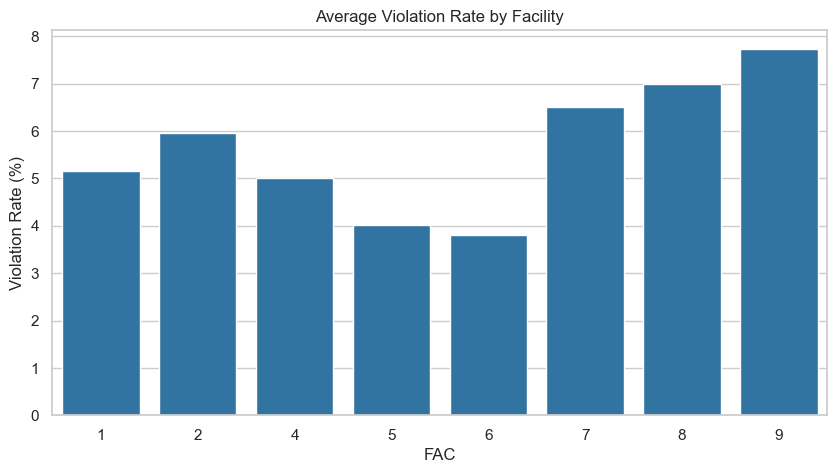

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=facility_summary.reset_index().sort_values("Violation_Rate_%", ascending=False),
    x="FAC",
    y="Violation_Rate_%"
)

plt.title("Average Violation Rate by Facility")
plt.ylabel("Violation Rate (%)")
plt.show()

### Variability & Operational Risk Interpretation

Traffic volume remains relatively stable across major facilities, with small facilities exhibiting higher proportional volatility.

In contrast, violation rates show substantially higher instability across multiple locations. Facilities such as FAC 1 and FAC 7 exhibit elevated violation variability, indicating greater compliance unpredictability.

The chart highlights clear facility-level heterogeneity, with Facilities 7, 8, and 9 exhibiting structurally higher violation rates compared to others, suggesting localized operational or compliance differences.
    
This suggests that operational risk within the system is driven more by behavioral volatility (violations) than by demand instability (traffic volume).

Understanding this distinction is critical for enforcement planning and forecasting reliability.

## Stage 8 — Correlation & Relationship Analysis

### Objective

After analyzing structural trends, seasonality, regime shifts, and facility-level variability, the next step is to examine how key variables interact with one another.

We aim to determine:

- Whether traffic volume is associated with violation rates
- Whether EZPass adoption is inversely related to violations
- Whether higher demand environments increase compliance risk

Understanding these relationships helps distinguish structural drivers from behavioral effects.

### Why This Matters

If violations are strongly correlated with traffic volume, compliance risk may be demand-driven.

If violations are more closely related to EZPass adoption levels, payment behavior may explain structural shifts.

This stage moves from descriptive analysis to interaction-based insight.

In [18]:
correlation_matrix = daily_traffic[
    ["TOTAL", "Violation_Rate_%", "EZPass_Rate_%"]
].corr()

correlation_matrix

,TOTAL,Violation_Rate_%,EZPass_Rate_%
TOTAL,1.00,-0.33,-0.03
Violation_Rate_%,-0.33,1.00,-0.03
EZPass_Rate_%,-0.03,-0.03,1.00


### Correlation Analysis — Key Findings

The correlation analysis reveals limited interaction between core variables:

- Traffic volume and violation rate exhibit a moderate negative relationship (−0.33), indicating that higher demand does not necessarily increase compliance risk.
- EZPass adoption shows near-zero correlation with both traffic volume and violation rate.
- Violation behavior does not appear to be mechanically driven by payment mode proportion.

These findings suggest that the structural shift in violation rates is likely driven by systemic or policy factors rather than demand intensity or payment composition alone.

### Traffic Volume vs Violation Rate

The correlation analysis indicated a moderate negative relationship between total traffic volume and violation rate (−0.33).

To visually confirm this relationship and assess its structural form (linear vs nonlinear), we plot a scatter diagram with a fitted regression line.

This allows us to evaluate:

- Whether the negative relationship is consistent
- Whether extreme periods drive the correlation
- Whether the relationship appears stable or clustered by regime

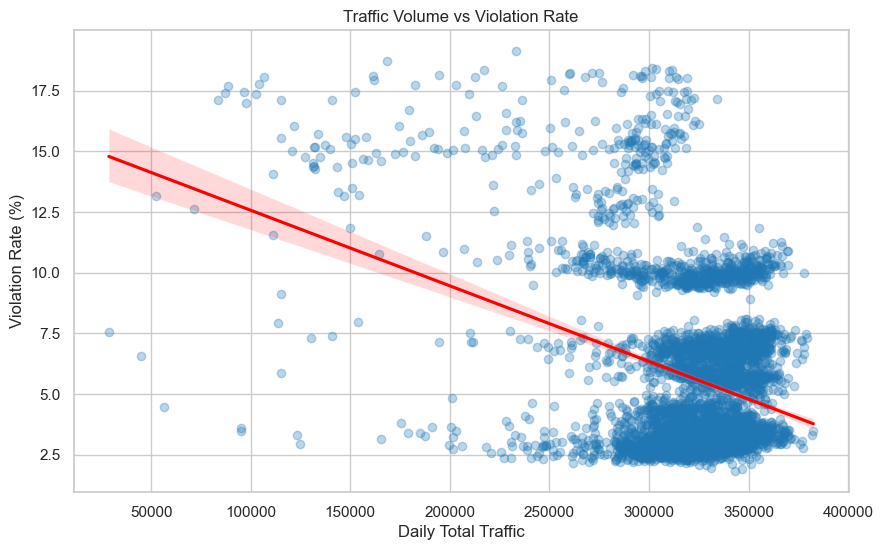

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(
    data=daily_traffic,
    x="TOTAL",
    y="Violation_Rate_%",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Traffic Volume vs Violation Rate")
plt.xlabel("Daily Total Traffic")
plt.ylabel("Violation Rate (%)")
plt.show()

### Scatter Interpretation — Demand vs Compliance

The regression line confirms a moderate negative relationship between traffic volume and violation rate.

However, the scatter distribution reveals distinct clustering, indicating that the relationship is influenced by structural regime shifts rather than continuous linear dynamics.

At high traffic levels, violation rates remain widely dispersed, suggesting that compliance behavior is not mechanically driven by demand intensity.

This supports the earlier conclusion that violation regime changes are likely structural rather than purely traffic-driven.

## Stage 9 — Outlier & Anomaly Detection

### Objective

While previous analysis identified structural trends and regime shifts, extreme deviations were visually observed but not formally quantified.

The objective of this stage is to statistically detect:

- Global outliers (extreme deviations from overall distribution)
- Temporal anomalies (sudden shocks relative to recent history)


### Methodology

We combine two approaches:

1. **Z-Score (Global Deviation)**  
   Identifies observations that deviate significantly from the overall mean.

2. **Rolling Z-Score (Time-Aware Deviation)**  
   Detects shocks relative to recent historical behavior using a moving window.

This ensures we capture both structural extremes and localized temporal disruptions.

In [23]:
import numpy as np

# --------------------------------------
# Global Z-Score Calculation
# --------------------------------------

daily_traffic["TOTAL_Z"] = (
    (daily_traffic["TOTAL"] - daily_traffic["TOTAL"].mean()) /
    daily_traffic["TOTAL"].std()
)

daily_traffic["Violation_Z"] = (
    (daily_traffic["Violation_Rate_%"] - daily_traffic["Violation_Rate_%"].mean()) /
    daily_traffic["Violation_Rate_%"].std()
)

# Flag extreme values (|Z| > 3)
daily_traffic["TOTAL_Outlier"] = np.abs(daily_traffic["TOTAL_Z"]) > 3
daily_traffic["Violation_Outlier"] = np.abs(daily_traffic["Violation_Z"]) > 3

daily_traffic[["DATE", "TOTAL", "TOTAL_Z", "TOTAL_Outlier"]].head()

,DATE,TOTAL,TOTAL_Z,TOTAL_Outlier
0,2013-01-01,251792,-1.91,False
1,2013-01-02,295380,-0.70,False
2,2013-01-03,302173,-0.52,False
3,2013-01-04,306485,-0.40,False
4,2013-01-05,289548,-0.86,False


In [24]:
daily_traffic["TOTAL_Outlier"].sum()
daily_traffic["Violation_Outlier"].sum()

np.int64(84)

### Global Outlier Visualization — TOTAL Traffic

Using Z-score threshold (|Z| > 3), 84 days were identified as extreme deviations from long-run traffic levels.

We now visualize these points to determine whether they represent isolated random extremes or concentrated structural shock periods.

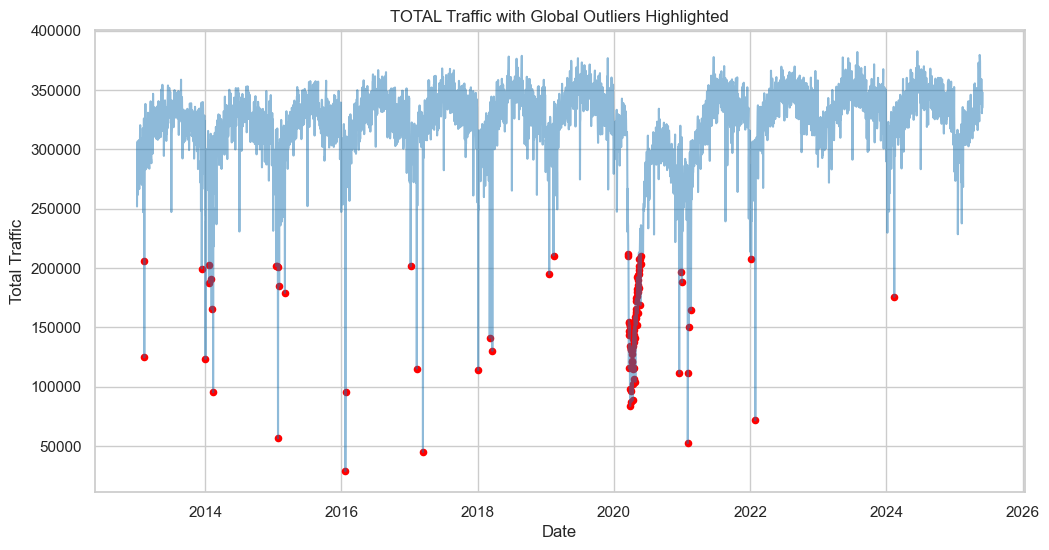

In [25]:
plt.figure(figsize=(12,6))

# Plot normal traffic
plt.plot(daily_traffic["DATE"], daily_traffic["TOTAL"], alpha=0.5)

# Highlight outliers
outliers = daily_traffic[daily_traffic["TOTAL_Outlier"]]
plt.scatter(outliers["DATE"], outliers["TOTAL"], color="red", s=20)

plt.title("TOTAL Traffic with Global Outliers Highlighted")
plt.xlabel("Date")
plt.ylabel("Total Traffic")
plt.show()

The majority of statistically extreme observations are concentrated around the 2020–2021 period, indicating a clear structural disruption in traffic levels during that interval.

Outside of this window, extreme deviations appear sporadic and isolated, suggesting that most outliers are tied to a distinct regime shift rather than continuous volatility.

## Rolling Z-Score — Localized Anomaly Detection

While global Z-scores capture extreme deviations from the long-run average, they may overlook short-term structural disruptions.  

To detect sudden instability relative to recent historical behavior, we compute a rolling Z-score using a moving window approach.

In [26]:
# --------------------------------------
# 30-Day Rolling Z-Score (Time-Aware)
# --------------------------------------

window = 30

daily_traffic["Rolling_Mean"] = daily_traffic["TOTAL"].rolling(window=window).mean()
daily_traffic["Rolling_Std"] = daily_traffic["TOTAL"].rolling(window=window).std()

daily_traffic["Rolling_Z"] = (
    (daily_traffic["TOTAL"] - daily_traffic["Rolling_Mean"]) /
    daily_traffic["Rolling_Std"]
)

# Flag rolling anomalies
daily_traffic["Rolling_Outlier"] = np.abs(daily_traffic["Rolling_Z"]) > 3

daily_traffic[["DATE", "TOTAL", "Rolling_Z", "Rolling_Outlier"]].head()

,DATE,TOTAL,Rolling_Z,Rolling_Outlier
0,2013-01-01,251792,NaN,False
1,2013-01-02,295380,NaN,False
2,2013-01-03,302173,NaN,False
3,2013-01-04,306485,NaN,False
4,2013-01-05,289548,NaN,False


The initial 29 observations contain NaN values because a 30-day rolling window requires sufficient prior data to compute local mean and standard deviation.  

This is expected behavior and does not indicate an error in computation.

In [27]:
daily_traffic["Rolling_Outlier"].sum()

np.int64(51)

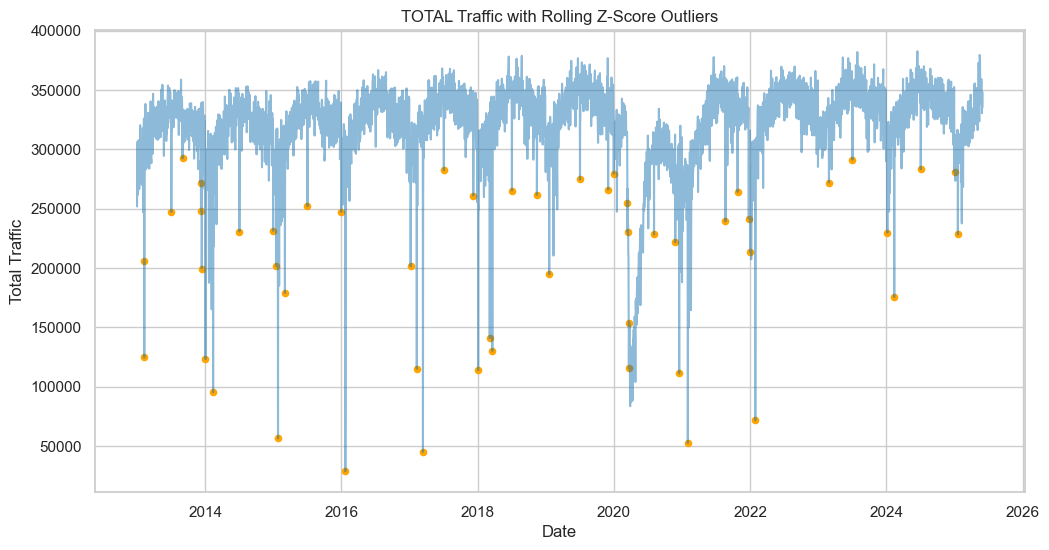

In [28]:
plt.figure(figsize=(12,6))

# Plot TOTAL
plt.plot(daily_traffic["DATE"], daily_traffic["TOTAL"], alpha=0.5)

# Highlight rolling outliers
rolling_outliers = daily_traffic[daily_traffic["Rolling_Outlier"]]
plt.scatter(rolling_outliers["DATE"], rolling_outliers["TOTAL"], color="orange", s=20)

plt.title("TOTAL Traffic with Rolling Z-Score Outliers")
plt.xlabel("Date")
plt.ylabel("Total Traffic")
plt.show()

The rolling Z-score identifies 51 localized anomalies, many concentrated around the 2020–2021 disruption period.  

Unlike the global Z-score, the rolling method captures sudden short-term instability relative to recent behavior, revealing additional localized shocks outside major regime shifts.

## Traffic Dataset — Formal Data Quality Audit

Before integrating multiple datasets, it is necessary to formally assess data quality to ensure reliability and consistency.

This section evaluates:

- Missing values
- Zero-value patterns
- Duplicate rows
- Basic structural consistency checks

In [29]:
# --------------------------------------
# Missing Value Summary
# --------------------------------------

missing_summary = daily_traffic.isnull().sum().to_frame(name="Missing_Count")
missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] / len(daily_traffic)
) * 100

missing_summary.sort_values("Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
Rolling_Z,29,0.64
Rolling_Std,29,0.64
Rolling_Mean,29,0.64
TOTAL_7D_MA,6,0.13
Violation_7D_MA,6,0.13
DATE,0,0.00
Regime,0,0.00
Violation_Outlier,0,0.00
TOTAL_Outlier,0,0.00
Violation_Z,0,0.00


In [30]:
# --------------------------------------
# Duplicate Row Detection
# --------------------------------------

duplicate_count = daily_traffic.duplicated().sum()

duplicate_count

np.int64(0)

### Data Quality Findings — Traffic Dataset

The core operational variables (TOTAL, CASH, EZPASS, VIOLATION, rates, DATE) contain no missing values, confirming structural completeness of the primary dataset.

The only missing values appear in rolling statistics (Rolling_Mean, Rolling_Std, Rolling_Z), which are expected due to window-based computations and do not reflect raw data issues.

Duplicate row detection returned zero duplicates, indicating data uniqueness at the daily observation level.

No data cleaning adjustments were required for the core traffic variables.

# 📊 Traffic Dataset – EDA Conclusion

## Key Structural Findings

- Core operational variables (TOTAL, CASH, EZPASS, VIOLATION) are complete with no missing values.
- No duplicate records were detected.
- Traffic volume exhibits structural variability across time.
- Clear regime differences are observable between earlier and later periods.
- Facilities differ meaningfully in traffic levels and violation behavior.
- Outliers and anomaly periods were identified but not treated at this stage.
- Class-level vehicle variables contain high sparsity and were excluded from system-level EDA.

## Important Notes for Next Phases

- Identified anomaly periods will require careful handling during cleaning.
- Regime shifts may need to be accounted for during modeling.
- Facility-level heterogeneity must be preserved during integration.
- Formal data cleaning will be performed in a separate dedicated notebook.

## Passenger Dataset – Structural Overview

The Passenger dataset operates at a **carrier-level weekly aggregation**.  
Each row represents total passenger volume for a specific carrier within a defined weekly date range (Start_Date to End_Date).

### Dataset Characteristics:
- Aggregation Level: Carrier × Weekly Period
- Continuous Variable: Volume
- Temporal Variables: Start_Date, End_Date
- Categorical Variable: Carrier

Unlike the Traffic dataset (lane-level granularity), this dataset reflects **aggregated commuter demand behavior** at the carrier level.

This dataset will help us:
- Understand weekly passenger demand trends
- Evaluate carrier-level dominance and variability
- Compare passenger flow behavior with bus volumes and traffic counts in later integration stages

### Variable Selection for Descriptive Analysis

For descriptive statistics and initial EDA, we focus primarily on:

- Volume → Represents total passenger demand per carrier per week

Date variables (Start_Date, End_Date) will be used for:
- Weekly trend analysis
- Temporal stability evaluation

Carrier will be used for:
- Comparative carrier-level analysis
- Concentration and variability assessment

No variables are excluded at this stage, as the dataset contains only four structured and analytically relevant columns.

In [31]:
# ===============================
# Passenger Descriptive Statistics
# ===============================

import numpy as np

passenger_stats = {
    "Mean": passenger_df["Volume"].mean(),
    "Median": passenger_df["Volume"].median(),
    "Std_Dev": passenger_df["Volume"].std(),
    "Variance": passenger_df["Volume"].var(),
    "Min": passenger_df["Volume"].min(),
    "Max": passenger_df["Volume"].max(),
    "Range": passenger_df["Volume"].max() - passenger_df["Volume"].min()
}

passenger_stats_df = pd.DataFrame(passenger_stats, index=["Passenger Volume"])
passenger_stats_df

,Mean,Median,Std_Dev,Variance,Min,Max,Range
Passenger Volume,"6,177.60",796.00,"18,033.24","325,197,779.34",0.00,"90,225.00","90,225.00"


### Descriptive Statistics Interpretation – Passenger Volume

The Passenger dataset exhibits a highly skewed distribution.

- The mean weekly passenger volume (6,177) is significantly higher than the median (796), indicating strong right-skewness.
- A small number of extremely high-volume weeks are inflating the average.
- The high standard deviation (18,033) and wide range (0 to 90,225) confirm substantial variability in weekly passenger demand.

This suggests the presence of:
- Outlier weeks or peak demand periods
- Potential structural shifts in commuter behavior

Given this variability, it is necessary to visualize the distribution and examine temporal patterns before proceeding to integration analysis.
We observed strong skewness in descriptive statistics.
Now we visualize the distribution to confirm whether passenger volume is concentrated at lower levels with few extreme spikes.

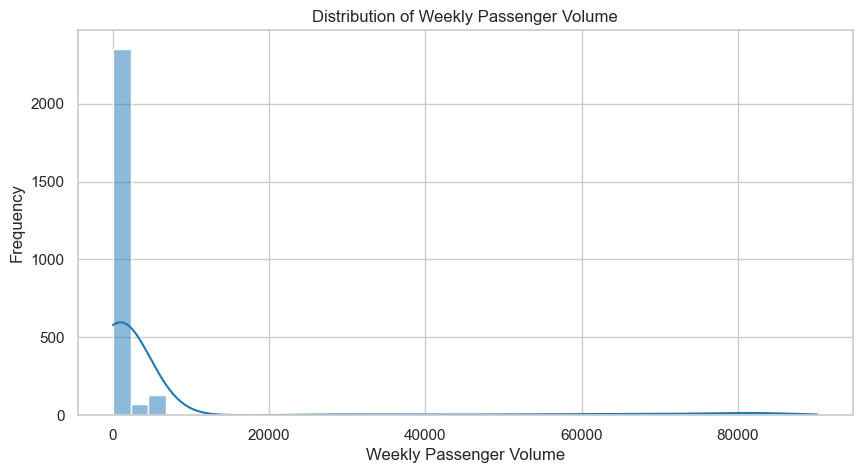

In [32]:
# ===============================
# Passenger Volume Distribution
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(passenger_df["Volume"], bins=40, kde=True)
plt.title("Distribution of Weekly Passenger Volume")
plt.xlabel("Weekly Passenger Volume")
plt.ylabel("Frequency")
plt.show()

### Passenger Volume Distribution Analysis

The histogram confirms a highly right-skewed distribution.

Most weekly passenger observations are concentrated at relatively low volume levels, while a small number of extreme weeks generate very large passenger counts. These extreme values create a long right tail and significantly inflate the mean.

This pattern suggests that passenger demand is not uniformly distributed across carriers or time periods, and further temporal analysis is required to determine whether these spikes are time-driven or carrier-specific.

Given the heavy skewness observed in the distribution, we now examine passenger volume behavior over time to determine whether extreme values are concentrated in specific periods.

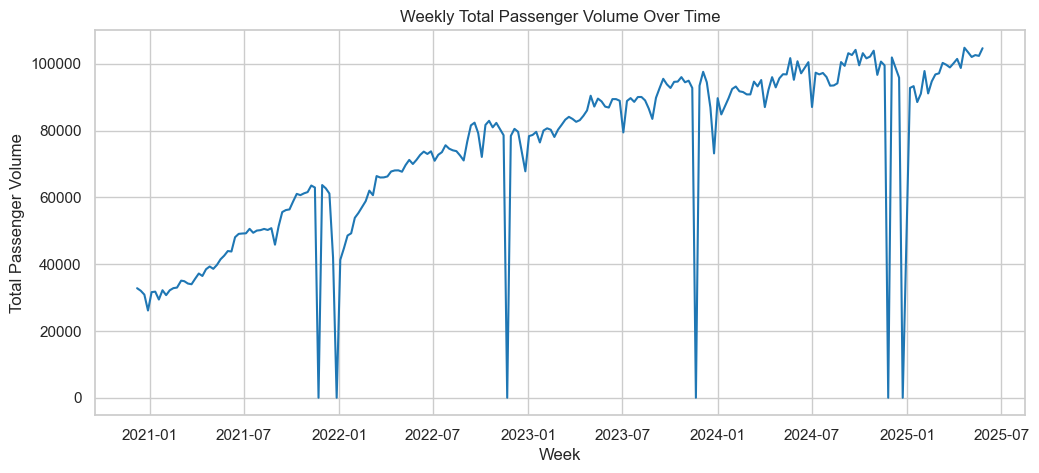

In [33]:
# ===============================
# Passenger Weekly Trend
# ===============================

# Create a weekly reference date
passenger_df["Week"] = passenger_df["Start_Date"]

weekly_passenger = passenger_df.groupby("Week")["Volume"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(weekly_passenger["Week"], weekly_passenger["Volume"])
plt.title("Weekly Total Passenger Volume Over Time")
plt.xlabel("Week")
plt.ylabel("Total Passenger Volume")
plt.show()

### Weekly Passenger Trend Analysis

The time-series visualization reveals a clear upward structural trend in weekly passenger demand from 2021 through 2025. Overall passenger volumes demonstrate sustained recovery and growth over time.

However, the series also contains several sharp and abrupt drops to near-zero levels. These drops appear structural rather than random fluctuations and may reflect reporting gaps, operational interruptions, or temporary service disruptions.

The presence of both a strong upward trend and intermittent structural breaks suggests that passenger demand behavior is evolving over time and requires careful handling during integration and comparative analysis.

## Carrier-Level Analysis

Given the strong skewness and upward demand trend, we now evaluate whether passenger volume concentration is driven by specific carriers.

Carrier-level analysis will help determine demand dominance and structural variability across operators.

In [34]:
# ===============================
# Carrier-Level Passenger Analysis
# ===============================

carrier_summary = passenger_df.groupby("Carrier")["Volume"].agg(
    Total_Volume="sum",
    Mean_Volume="mean",
    Median_Volume="median",
    Std_Dev="std",
    Observations="count"
).reset_index()

carrier_summary = carrier_summary.sort_values(by="Total_Volume", ascending=False)

carrier_summary

,Carrier,Total_Volume,Mean_Volume,Median_Volume,Std_Dev,Observations
11,NJTransit,"12,985,016.00","60,395.42","65,994.00","21,203.93",215
10,NJ Transit,"1,452,175.00","85,422.06","85,657.00","3,111.10",17
4,Coach USA,"972,252.00","4,190.74","4,723.00","1,451.07",232
7,HCEE - Community,"330,976.00","1,426.62","1,496.50",318.20,232
6,Greyhound,"320,417.40","1,381.11","1,387.00",420.41,232
0,Academy,"245,524.20","1,076.86","1,152.00",321.97,228
8,Lakeland,"240,602.00","1,037.08","1,192.50",424.12,232
12,Peter Pan_Bonanza,"201,468.00",868.40,792.50,410.78,232
9,Martz,"160,137.00",690.25,737.00,150.80,232
14,TransBridge,"129,736.00",559.21,607.00,144.64,232


### Carrier-Level Passenger Analysis

Carrier-level aggregation reveals strong demand concentration.

NJTransit dominates the dataset, accounting for the vast majority of total passenger volume (~12.98 million). The next highest carrier operates at a significantly lower scale, confirming that overall passenger demand patterns are heavily influenced by NJTransit behavior.

The distribution across other carriers is highly uneven, with most operators contributing relatively small volumes.

Additionally, multiple instances of similar carrier names (e.g., NJTransit vs NJ Transit, Academy appearing twice) and carriers with very low observation counts indicate potential naming inconsistencies and structural fragmentation. These issues should be addressed during the data cleaning and standardization phase prior to integration.

### Variability by Carrier
After identifying strong carrier concentration, we now evaluate variability in passenger demand across carriers.
Understanding volatility helps determine operational stability and risk exposure at the carrier level.

In [35]:
# ===============================
# Carrier Variability Analysis
# ===============================

carrier_variability = passenger_df.groupby("Carrier")["Volume"].agg(
    Mean="mean",
    Std="std"
).reset_index()

carrier_variability["CV"] = carrier_variability["Std"] / carrier_variability["Mean"]

carrier_variability = carrier_variability.sort_values(by="CV", ascending=False)

carrier_variability

,Carrier,Mean,Std,CV
3,C&J Bus Lines,0.13,0.96,7.36
5,DeCamp,181.40,250.56,1.38
12,Peter Pan_Bonanza,868.40,410.78,0.47
8,Lakeland,"1,037.08",424.12,0.41
11,NJTransit,"60,395.42","21,203.93",0.35
4,Coach USA,"4,190.74","1,451.07",0.35
13,Trailways,484.36,160.30,0.33
6,Greyhound,"1,381.11",420.41,0.30
0,Academy,"1,076.86",321.97,0.30
14,TransBridge,559.21,144.64,0.26


### Carrier-Level Variability Analysis

Carrier variability analysis using the coefficient of variation (CV) reveals distinct stability patterns.

Carriers with very low average volumes (e.g., C&J Bus Lines and DeCamp) exhibit extremely high CV values, indicating unstable or sparse operational behavior. These carriers may require special treatment during cleaning or integration due to data fragmentation or low observation counts.

Most mid-sized carriers demonstrate moderate variability (CV between 0.30–0.47), reflecting realistic operational fluctuation.

**Note**: One carrier displays a NaN coefficient of variation (CV). This occurs because both the mean and standard deviation of volume are zero, resulting in an undefined division (0 ÷ 0). 
This indicates that the carrier recorded no operational volume during the observed period and should be reviewed during the data cleaning phase to determine whether it represents a valid inactive carrier or a structural placeholder.
    
NJTransit, despite dominating total passenger volume, maintains relatively stable variability. This confirms that system-level passenger trends are primarily driven by NJTransit behavior but remain structurally consistent over time.

## Passenger Dataset – Key Structural Insights & EDA Conclusion

The Passenger dataset operates at a weekly carrier-level aggregation and demonstrates strong structural concentration.

Key findings include:

- Passenger demand is highly right-skewed, with a small number of extreme weekly values significantly influencing the mean.
- A clear upward structural trend is observed over time, indicating sustained recovery and growth in passenger demand.
- Demand is heavily concentrated within NJTransit, which dominates total system passenger volume.
- Several carriers exhibit naming inconsistencies and fragmented records, requiring standardization during the data cleaning phase.
- Variability analysis reveals that large carriers maintain operational stability, while smaller carriers show extreme volatility due to low observation counts.

Overall, the Passenger dataset is structurally informative but requires carrier name standardization and careful handling of sparse operators before integration with Traffic, Bus, and Speeds datasets.

## Bus Dataset – Structural Overview

The Bus dataset operates at a **carrier-level weekly aggregation**, similar to the Passenger dataset.

Each row represents total bus volume for a specific carrier within a defined weekly date range (Start_Date to End_Date).

### Dataset Characteristics:
- Aggregation Level: Carrier × Weekly Period
- Continuous Variable: Volume
- Temporal Variables: Start_Date, End_Date
- Categorical Variable: Carrier

This dataset reflects operational bus activity and will allow us to:
- Examine weekly bus volume trends
- Evaluate carrier-level dominance
- Compare bus demand behavior with passenger demand in later stages

### Variable Selection for Descriptive Analysis

The primary analytical variable is:

- Volume → Represents total weekly bus volume per carrier.

Start_Date and End_Date will be used for:
- Weekly trend analysis
- Temporal stability evaluation

Carrier will be used for:
- Carrier-level aggregation
- Demand concentration analysis

No variables are excluded, as all fields are structurally relevant.

We begin by examining the central tendency and variability of weekly bus volume to understand overall demand distribution and dispersion.

In [36]:
# ===============================
# Bus Descriptive Statistics
# ===============================

bus_stats = {
    "Mean": bus_df["Volume"].mean(),
    "Median": bus_df["Volume"].median(),
    "Std_Dev": bus_df["Volume"].std(),
    "Variance": bus_df["Volume"].var(),
    "Min": bus_df["Volume"].min(),
    "Max": bus_df["Volume"].max(),
    "Range": bus_df["Volume"].max() - bus_df["Volume"].min()
}

bus_stats_df = pd.DataFrame(bus_stats, index=["Bus Volume"])
bus_stats_df

,Mean,Median,Std_Dev,Variance,Min,Max,Range
Bus Volume,221.71,29.00,614.33,"377,395.59",0.00,"2,577.00","2,577.00"


### Descriptive Statistics Interpretation – Bus Volume

The Bus dataset exhibits a strongly right-skewed distribution.

The mean weekly bus volume (221) is significantly higher than the median (29), indicating that most observations are low-volume weeks with occasional high-volume spikes. The large standard deviation (614) relative to the mean confirms substantial variability in weekly bus activity.

The wide range (0 to 2,577) further supports the presence of uneven operational intensity across carriers or time periods.

Overall, bus demand appears volatile and concentrated within specific carriers or weeks rather than uniformly distributed.

Given the strong skewness observed in descriptive statistics, we visualize the distribution of weekly bus volume to confirm concentration at lower values and identify extreme spikes.

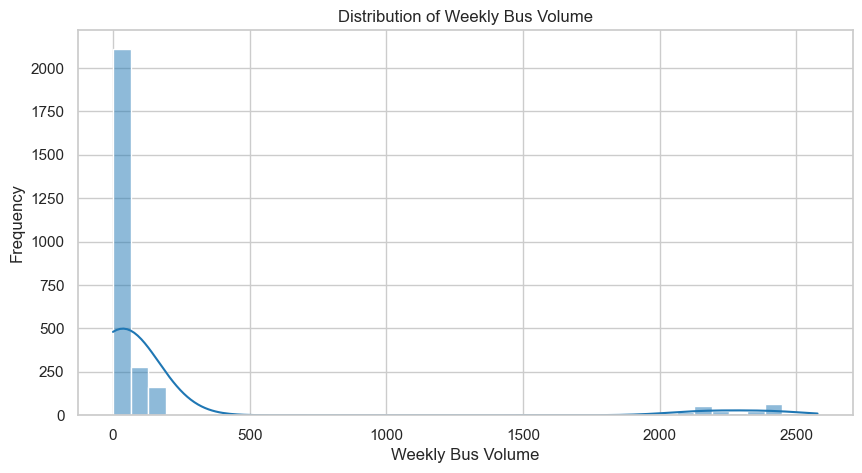

In [37]:
# ===============================
# Bus Volume Distribution
# ===============================

plt.figure(figsize=(10,5))
sns.histplot(bus_df["Volume"], bins=40, kde=True)
plt.title("Distribution of Weekly Bus Volume")
plt.xlabel("Weekly Bus Volume")
plt.ylabel("Frequency")
plt.show()

### Bus Volume Distribution Analysis

The histogram confirms a strongly right-skewed distribution of weekly bus volume.

Most observations are concentrated at very low volume levels, while a small number of extreme weeks generate significantly higher bus counts. These spikes create a long right tail and inflate the mean relative to the median.

This indicates that bus activity is not evenly distributed across carriers or weeks and may be driven by a limited number of high-volume operators.

### Weekly Bus Trend Over Time

Because skewness alone does not tell us whether:

- Growth trend exists
- Volatility is structural
- There are temporal disruptions

To understand whether bus volume variability is time-driven, we now examine weekly total bus volume trends over time.

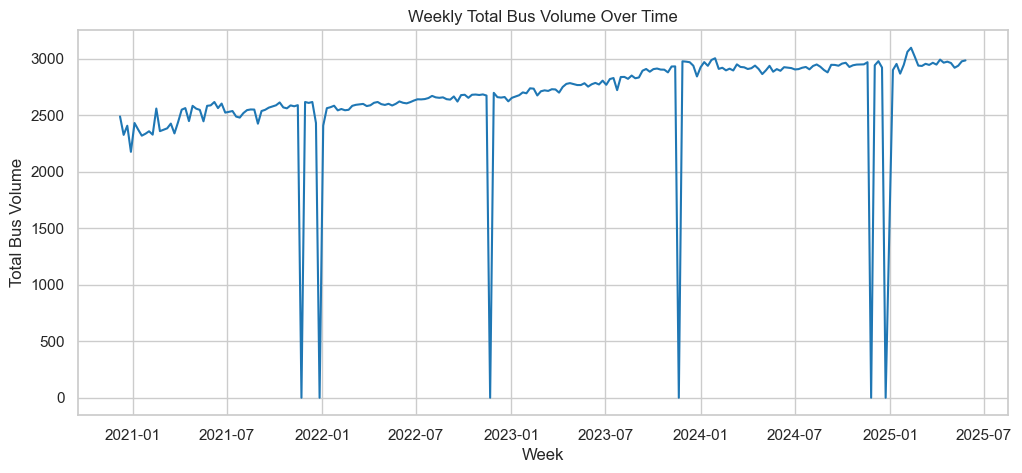

In [38]:
# ===============================
# Weekly Bus Trend
# ===============================

bus_df["Week"] = bus_df["Start_Date"]

weekly_bus = bus_df.groupby("Week")["Volume"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(weekly_bus["Week"], weekly_bus["Volume"])
plt.title("Weekly Total Bus Volume Over Time")
plt.xlabel("Week")
plt.ylabel("Total Bus Volume")
plt.show()

### Weekly Bus Trend Analysis

The time-series visualization reveals a steady upward trend in total weekly bus volume from 2021 through 2025. Bus demand shows gradual growth and relative stability over time.

Similar to the Passenger dataset, several abrupt drops to near-zero levels are observed. These drops appear structural rather than random fluctuations and may reflect reporting gaps or temporary operational interruptions.

Overall, bus volume behavior appears more stable and less volatile than passenger volume, although both datasets exhibit similar structural breaks at certain time points.

### Carrier-Level Concentration

To confirm whether:
- One carrier dominates (like NJTransit did in Passenger)
- Or bus operations are more diversified

To evaluate operational concentration in bus services, we now examine total and average volume by carrier.

In [39]:
# ===============================
# Bus Carrier-Level Analysis
# ===============================

bus_carrier_summary = bus_df.groupby("Carrier")["Volume"].agg(
    Total_Volume="sum",
    Mean_Volume="mean",
    Median_Volume="median",
    Std_Dev="std",
    Observations="count"
).reset_index()

bus_carrier_summary = bus_carrier_summary.sort_values(by="Total_Volume", ascending=False)

bus_carrier_summary

,Carrier,Total_Volume,Mean_Volume,Median_Volume,Std_Dev,Observations
9,NJ Transit,"515,189.00","2,220.64","2,256.50",387.22,232
3,Coach USA,"32,892.00",141.78,147.00,40.81,232
6,HCEE - Community,"18,901.00",81.47,85.00,15.95,232
5,Greyhound,"12,029.00",51.85,54.50,11.53,232
0,Academy,"8,419.00",36.93,36.00,8.18,228
7,Lakeland,"7,180.00",30.95,29.00,11.20,232
10,Peter Pan_Bonanza,"6,293.40",27.13,26.00,9.98,232
11,Trailways,"4,712.00",20.31,22.00,5.39,232
12,TransBridge,"4,413.00",19.02,19.00,4.84,232
8,Martz,"4,011.00",17.29,18.00,3.49,232


### Bus Carrier-Level Analysis

Carrier-level aggregation reveals strong operational concentration within NJ Transit.

NJ Transit accounts for the vast majority of total bus volume (515,189), significantly exceeding all other carriers. The next largest operator (Coach USA) operates at a substantially smaller scale, indicating high concentration within a single dominant carrier.

Similar to the Passenger dataset, bus operations are not evenly distributed across carriers. Several smaller carriers contribute minimal volume, and naming inconsistencies (e.g., Academy appearing twice) suggest structural standardization will be required during the cleaning phase.

Overall, system-level bus behavior is heavily influenced by NJ Transit operations.

## Bus Dataset – Key Structural Insights & EDA Conclusion

The Bus dataset operates at a weekly carrier-level aggregation and demonstrates strong concentration patterns.

Key findings include:

- Weekly bus volume is highly right-skewed, with most observations at low levels and occasional high-volume spikes.
- A steady upward trend in bus demand is observed from 2021 to 2025.
- NJ Transit dominates bus operations, accounting for the majority of total system volume.
- Several low-volume carriers exhibit sparse operational activity and require review during cleaning.
- Structural similarities between Bus and Passenger datasets indicate strong compatibility for future integration and comparative analysis.

The dataset is structurally stable but requires carrier name standardization and review of low-volume operators before integration.

## Speeds Dataset – Structural Overview

The Speeds dataset operates at a **facility-level monthly aggregation**.

Each row represents mobility metrics for a specific facility and direction during a given month.

### Dataset Characteristics:
- Aggregation Level: Facility × Direction × Month
- Temporal Variable: Month_Year
- Continuous Variables:
  - Avg_Speed → Observed average vehicle speed
  - Freeflow → Baseline free-flow speed
  - Delta → Difference between freeflow and observed speed
- Categorical Variables:
  - Facility
  - Direction

Unlike Traffic, Passenger, and Bus datasets, this dataset captures mobility performance rather than volume demand.

### Variable Selection for Descriptive Analysis

The primary analytical variables include:

- Avg_Speed → Represents observed operational speed
- Freeflow → Represents ideal baseline speed
- Delta → Measures deviation from optimal conditions

Month_Year will be used for temporal trend analysis.
Facility and Direction will be used for facility-level performance comparisons.

All variables are structurally relevant and will be included in analysis.

We begin by evaluating central tendency and dispersion of observed speeds to understand overall system mobility behavior.

In [40]:
# ===============================
# Speeds Descriptive Statistics
# ===============================

speed_stats = speeds_df[["Avg_Speed", "Freeflow", "Delta"]].describe()

speed_stats

,Avg_Speed,Freeflow,Delta
count,192.00,192.00,192.00
mean,35.73,42.02,-6.52
std,11.74,5.39,8.90
min,13.20,32.00,-27.30
25%,24.10,38.73,-13.90
50%,39.20,44.90,-4.90
75%,47.10,45.23,1.73
max,49.50,47.90,4.10


### Speeds Descriptive Statistics Interpretation

The Speeds dataset indicates consistent deviation from optimal mobility conditions.

The average observed speed (35.73 mph) is notably lower than the average free-flow speed (42.02 mph), resulting in a mean Delta of -6.52 mph. This suggests that vehicles operate below ideal conditions on average.

The wide range in Avg_Speed (13.20 to 49.50 mph) and a minimum Delta of -27.30 indicate substantial congestion variability across facilities and time periods.

Overall, the system exhibits measurable congestion, with variability suggesting that mobility performance differs significantly by facility and month.

## Monthly Trend of Avg_Speed

To evaluate whether congestion conditions are improving or deteriorating over time, we now examine the monthly trend of observed average speed.

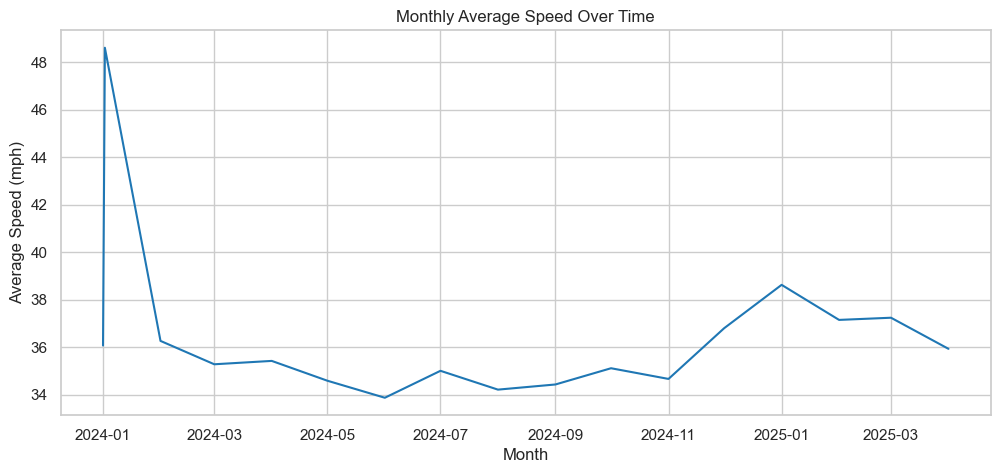

In [41]:
# ===============================
# Monthly Speed Trend
# ===============================

monthly_speed = speeds_df.groupby("Month_Year")["Avg_Speed"].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_speed["Month_Year"], monthly_speed["Avg_Speed"])
plt.title("Monthly Average Speed Over Time")
plt.xlabel("Month")
plt.ylabel("Average Speed (mph)")
plt.show()

### Monthly Average Speed Trend Analysis

The monthly speed trend indicates relatively stable mobility conditions over the observed period.

An initial spike in early 2024 is followed by normalization, after which average speeds fluctuate within a narrow band between approximately 34 and 38 mph. No sustained downward trend is observed, suggesting that congestion levels remain relatively stable over time.

Overall, system mobility appears consistent, with moderate month-to-month variation but no clear long-term deterioration during the observed window.

## Facility-Level Speed Comparison

To identify congestion concentration within the system, we now compare average speed levels across facilities.

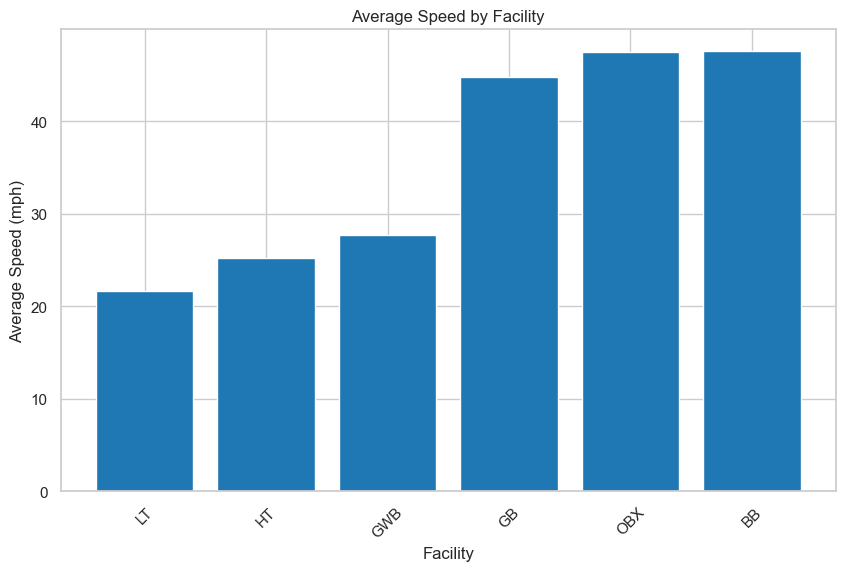

,Facility,Avg_Speed
4,LT,21.62
3,HT,25.27
2,GWB,27.70
1,GB,44.76
5,OBX,47.50
0,BB,47.56


In [42]:
# ===============================
# Facility-Level Average Speed
# ===============================

facility_speed = speeds_df.groupby("Facility")["Avg_Speed"].mean().reset_index()
facility_speed = facility_speed.sort_values(by="Avg_Speed")

plt.figure()
plt.bar(facility_speed["Facility"], facility_speed["Avg_Speed"])
plt.title("Average Speed by Facility")
plt.xlabel("Facility")
plt.ylabel("Average Speed (mph)")
plt.xticks(rotation=45)
plt.show()

facility_speed

### Facility-Level Mobility Comparison

Facility-level analysis reveals significant variation in mobility performance.

LT, HT, and GWB operate at substantially lower average speeds (21–28 mph), indicating persistent congestion at these facilities. In contrast, OBX, BB, and GB maintain average speeds near 45–48 mph, suggesting near free-flow operating conditions.

This indicates that congestion is not system-wide but highly concentrated within specific facilities. Integration with traffic volume data will help determine whether higher demand levels are associated with these lower-speed corridors.

## Speeds Dataset – Key Structural Insights & EDA Conclusion

The Speeds dataset operates at a monthly facility-level aggregation and captures system mobility performance.

Key findings include:

- Observed speeds are consistently lower than free-flow speeds, with an average deviation of -6.52 mph, indicating measurable congestion.
- Monthly speed trends remain relatively stable over time, with no clear long-term deterioration in mobility conditions.
- Congestion is highly facility-specific, with LT, HT, and GWB experiencing significantly lower speeds compared to OBX, BB, and GB.
- The system exhibits heterogeneous performance rather than uniform congestion.

Overall, mobility performance varies by facility but remains structurally stable during the observed period. These findings will be essential when comparing demand growth from Traffic, Passenger, and Bus datasets with congestion behavior.

## 🔎 Cross-Dataset Structural Alignment & Integration Blueprint

This section formally documents how all four internal datasets relate to each other, 
what structural mismatches exist, and how they will be harmonized before cleaning 
and integration. This is critical for ensuring referential integrity and analytical consistency.


## 1️⃣ Dataset Structural Overview

| Dataset     | Time Granularity | Key Metric(s)              | Grouping Variables | Volume Scale |
|------------|-----------------|----------------------------|--------------------|--------------|
| Traffic    | Daily          | TOTAL, VIOLATION, EZPASS   | DATE, Facility     | Very High (~300k/day) |
| Passenger  | Weekly         | Passenger Volume           | Week, Carrier      | High (~100k/week) |
| Bus        | Weekly         | Bus Volume                 | Week, Carrier      | Moderate (~3k/week) |
| Speeds     | Monthly        | Avg_Speed, Freeflow, Delta | Month, Facility    | Continuous Metric |


## 2️⃣ Structural Relationships Across Datasets

### A. Traffic ↔ Speeds

**Common Link:** Facility  
- Both datasets include facility-level information.
- Traffic contains daily vehicle counts by facility.
- Speeds contains monthly average speed by facility.

**Integration Strategy:**
- Aggregate Traffic from Daily → Monthly by Facility.
- Merge on: `Facility + Year-Month`.

This allows:
- Examining how traffic volume affects average speeds.
- Studying congestion-speed relationships.


### B. Passenger ↔ Bus

**Common Link:** Carrier + Week

- Both datasets operate at weekly granularity.
- Passenger dataset measures total riders.
- Bus dataset measures bus vehicle counts.

**Integration Strategy:**
- Standardize carrier naming (e.g., "NJTransit" vs "NJ Transit").
- Merge on: `Week + Carrier`.

This allows:
- Evaluating passenger-to-bus efficiency ratios.
- Studying load factors and service intensity.


### C. Traffic ↔ Passenger/Bus

**Indirect Relationship:** Time

- Traffic is Daily.
- Passenger and Bus are Weekly.

**Integration Strategy:**
- Aggregate Traffic to Weekly level.
- Merge on: `Year + Week`.

This allows:
- Studying how total vehicle traffic correlates with transit usage.
- Evaluating modal shifts during high/low traffic periods.


### D. Traffic ↔ Violation Rates ↔ Speeds

Traffic dataset includes:
- Violation Rate %
- EZPass Rate %
- Cash Rate %

Speeds dataset includes:
- Avg Speed
- Freeflow Speed
- Speed Delta

Integration at Monthly level enables:
- Studying whether lower speeds correlate with higher violations.
- Identifying congestion-related enforcement patterns.


## 3️⃣ Granularity Harmonization Plan

Before integration, all datasets must align temporally.

| Target Level | Datasets to Align | Method |
|-------------|-------------------|--------|
| Weekly      | Traffic → Passenger/Bus | Aggregate daily traffic to weekly totals |
| Monthly     | Traffic → Speeds | Aggregate daily traffic to monthly totals |
| Daily       | Weather → Traffic | Merge directly on DATE |

This ensures no loss of structural consistency.


## 4️⃣ Identified Cleaning Requirements Before Integration

### Traffic Dataset
- Handle structural nulls in Class variables (high sparsity).
- Decide on treatment of outliers (flag vs cap vs retain).
- Validate rolling metrics (NaNs in first window are expected).

### Passenger Dataset
- Investigate structural zero weeks (true zero vs missing reporting).
- Normalize carrier naming inconsistencies.

### Bus Dataset
- Resolve duplicate carrier naming.
- Remove carriers with all-zero activity (if structurally irrelevant).

### Speeds Dataset
- Validate Delta = Avg_Speed - Freeflow.
- Ensure facility naming matches Traffic dataset.


### 5️⃣ Weather Dataset Integration Logic

#### Why Weather is Structurally Justified

Weather directly impacts:
- Traffic volume
- Passenger usage
- Bus operations
- Average speeds

### Required Weather Variables (Daily Level)
- Daily Avg Temperature
- Precipitation (Rain/Snow)
- Snowfall Indicator
- Severe Weather Flag

### Weather Integration Plan

| Dataset | Weather Merge Level |
|----------|--------------------|
| Traffic  | Direct (Daily) |
| Passenger | Weekly aggregated weather |
| Bus | Weekly aggregated weather |
| Speeds | Monthly aggregated weather |

This preserves temporal integrity and avoids data leakage.


## 6️⃣ Referential Integrity Strategy

To ensure consistent merging:

1. Create standardized `DATE`, `Year`, `Week`, `Year-Month` fields across all datasets.
2. Standardize Facility names across Traffic and Speeds.
3. Standardize Carrier names across Passenger and Bus.
4. Maintain primary keys:
   - Traffic: DATE + Facility
   - Passenger: Week + Carrier
   - Bus: Week + Carrier
   - Speeds: Month + Facility

This prevents duplication and ensures consistent joins.


## 7️⃣ Integration Architecture (Conceptual)

Weather (Daily)
        ↓
Traffic (Daily)
        ↓ (Aggregate Weekly)
Passenger / Bus (Weekly)
        ↓ (Aggregate Monthly)
Speeds (Monthly)

This architecture ensures:
- Logical data flow
- No temporal distortion
- Clean analytical alignment


## ✅ Conclusion

All four datasets are structurally compatible, but only after:

- Temporal harmonization
- Naming normalization
- Outlier and zero-value assessment
- Controlled aggregation

The addition of Weather strengthens causal interpretation and provides 
explanatory variables for volume, violation, and speed fluctuations.

This documented structure directly informs the upcoming Data Cleaning 
and Integration Phase.

---